# Savegame Analysis Workbench

Build or refresh the raw savegame parquet dataset first:

```bash
uv run ppc savegame-notebooks build
```

All analysis below uses Polars lazy scans over `graphs/dataset`. Change selector variables in the setup cell, then rerun the relevant section.

In [1]:
%matplotlib inline

import importlib
import matplotlib.pyplot as plt
from eu5gameparser.savegame import notebook_workbench as wb
wb = importlib.reload(wb)

NOTEBOOK_FIGSIZE = (22, 8.5)
NOTEBOOK_MIN_FIGURE_WIDTH = 22
NOTEBOOK_MIN_FIGURE_HEIGHT = 8.5

plt.rcParams["figure.figsize"] = NOTEBOOK_FIGSIZE
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 140

_original_subplots = getattr(plt, "_ppc_original_subplots", plt.subplots)


def _ppc_wide_subplots(*args, **kwargs):
    figsize = kwargs.get("figsize")
    if figsize is None:
        figsize = NOTEBOOK_FIGSIZE
    else:
        figsize = (
            max(float(figsize[0]), NOTEBOOK_MIN_FIGURE_WIDTH),
            max(float(figsize[1]), NOTEBOOK_MIN_FIGURE_HEIGHT),
        )
    kwargs["figsize"] = figsize
    return _original_subplots(*args, **kwargs)


plt._ppc_original_subplots = _original_subplots
plt.subplots = _ppc_wide_subplots
wb.plt.subplots = _ppc_wide_subplots

DATA_ROOT = None       # None means graphs/dataset under the constructor repo
LOAD_ORDER_PATH = None # None means constructor.load_order.toml under the constructor repo
PLAYTHROUGH = None     # None means latest playthrough
START_DATE = None      # example: 13370101
END_DATE = None        # example: 14000101
SNAPSHOT_DATE = None   # None means latest selected snapshot

GOOD_SEARCH = "victuals"
MARKET_SEARCH = None   # None means all markets; set to e.g. "london" for market drilldowns
BUILDING_SEARCH = "cookery"
BUILDING_TAG_FILTER = None  # e.g. "farming_capacity"; set BUILDING_SEARCH = None to plot the whole tag
PM_DRILLDOWN_SEARCH = None  # set to e.g. "packing" only for PM flow/value drilldowns
COUNTRY_SEARCH = "england"

GROUP_BY = "super_region"
BUILDING_SCOPE = "super_region"
FLOW_GROUP_BY = ("flow_table", "market")
CONSUMPTION_GROUP_BY = "bucket"
IMBALANCE_SORT = "mean_flow"  # mean_flow, total_flow, mean_market_cap, total_market_cap
AGG = "sum"           # sum, mean, median over raw selected rows
TOP_N = 6
BUCKET_YEARS = 25
START_YEAR = 1337
POPULATION_METRIC = "total_population"
FOOD_RANK_BY = "food_fill_ratio"
BUILDING_METRIC = "level"

workbench = wb.open_workbench(wb.WorkbenchConfig.from_mapping(globals()))
ds = workbench.dataset
snapshots = workbench.snapshots


## Savegame Runtime Cadence

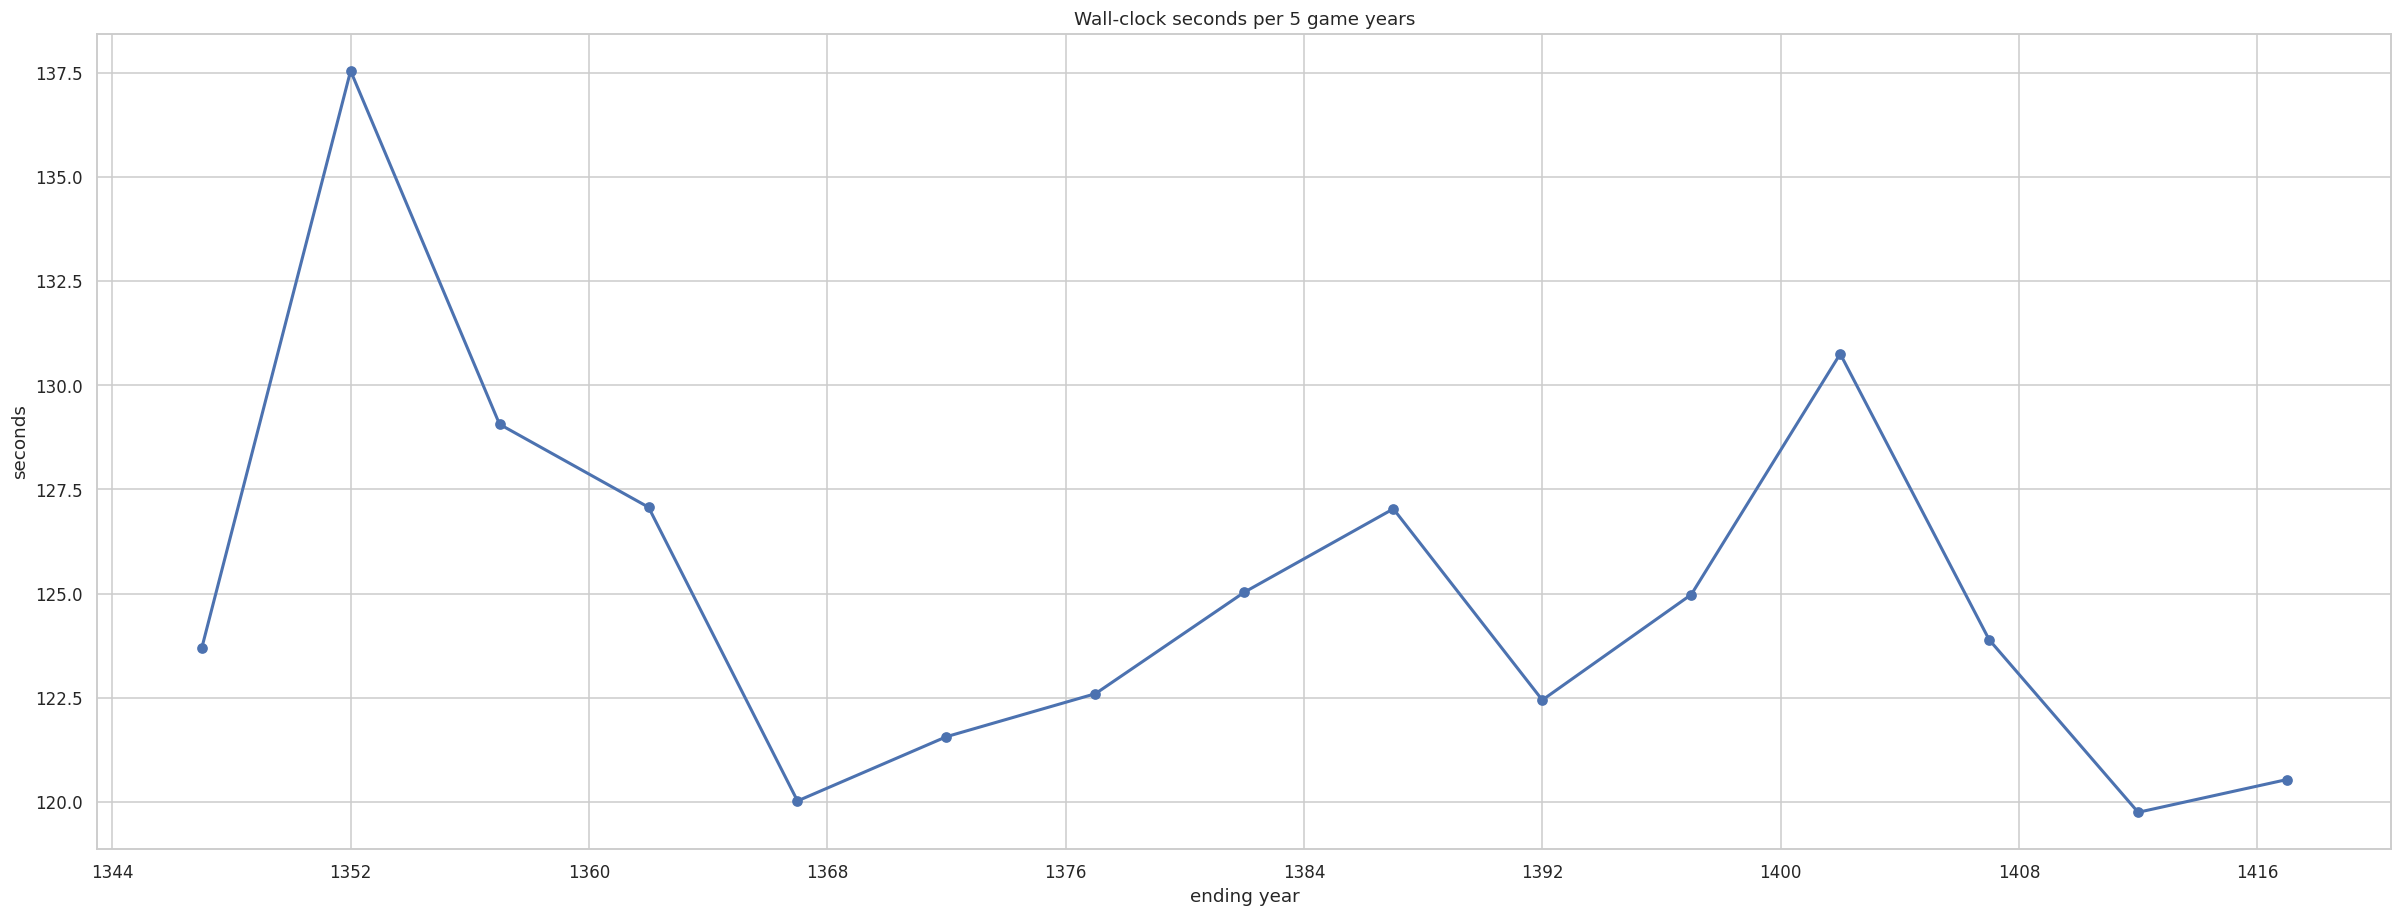

intervals,min_seconds,mean_seconds,median_seconds,max_seconds,stddev_seconds
u32,f64,f64,f64,f64,f64
15,119.75,125.06,123.89,137.54,4.74


In [2]:
import matplotlib.pyplot as plt
import polars as pl
from IPython.display import display
from matplotlib.ticker import MaxNLocator

SAVEGAME_INTERVAL_YEARS = 5


def _selected_snapshots() -> pl.DataFrame:
    frame = snapshots.filter(pl.col("playthrough_id") == workbench.playthrough).sort("date_sort")
    if START_DATE is not None:
        frame = frame.filter(pl.col("date_sort") >= int(START_DATE))
    if END_DATE is not None:
        frame = frame.filter(pl.col("date_sort") <= int(END_DATE))
    return frame


savegame_cadence = (
    _selected_snapshots()
    .select(["snapshot_id", "date", "year", "month", "day", "date_sort", "mtime_ns", "path"])
    .with_columns(
        pl.col("date").shift(1).alias("previous_date"),
        pl.col("year").shift(1).alias("previous_year"),
        pl.col("date_sort").shift(1).alias("previous_date_sort"),
        pl.col("mtime_ns").shift(1).alias("previous_mtime_ns"),
    )
    .with_columns(
        pl.concat_str(["previous_date", pl.lit(" -> "), "date"]).alias("interval"),
        (pl.col("year").cast(pl.Int64) - pl.col("previous_year").cast(pl.Int64)).alias("elapsed_game_years"),
        ((pl.col("mtime_ns") - pl.col("previous_mtime_ns")).cast(pl.Float64) / 1_000_000_000.0).alias("elapsed_seconds"),
    )
    .filter(pl.col("elapsed_seconds").is_not_null())
)
savegame_cadence_5_years = savegame_cadence.filter(pl.col("elapsed_game_years") == SAVEGAME_INTERVAL_YEARS)
savegame_cadence_plot = savegame_cadence_5_years if not savegame_cadence_5_years.is_empty() else savegame_cadence

if savegame_cadence_plot.is_empty():
    print("No savegame interval rows")
    savegame_cadence_stats = pl.DataFrame()
else:
    fig, ax = plt.subplots(figsize=(11, 4.2))
    ax.plot(
        savegame_cadence_plot["year"].to_list(),
        savegame_cadence_plot["elapsed_seconds"].to_list(),
        marker="o",
        linewidth=2.0,
    )
    ax.set_title(f"Wall-clock seconds per {SAVEGAME_INTERVAL_YEARS} game years")
    ax.set_xlabel("ending year")
    ax.set_ylabel("seconds")
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    fig.tight_layout()
    display(fig, include=["image/png"])
    plt.close(fig)

    savegame_cadence_stats = savegame_cadence_plot.select(
        pl.len().alias("intervals"),
        pl.min("elapsed_seconds").round(2).alias("min_seconds"),
        pl.mean("elapsed_seconds").round(2).alias("mean_seconds"),
        pl.median("elapsed_seconds").round(2).alias("median_seconds"),
        pl.max("elapsed_seconds").round(2).alias("max_seconds"),
        pl.std("elapsed_seconds").round(2).alias("stddev_seconds"),
    )
    display(savegame_cadence_stats)


## Search And Snapshot Context

In [3]:
workbench.print_selection()
goods_matches, market_matches, building_matches, pm_matches, country_matches, snapshot_summary = workbench.preview()


repo: /home/jan/development/ProsperOrPerishConstructor
data: /home/jan/development/ProsperOrPerishConstructor/graphs/dataset
data mode: raw
playthrough: a818a7e2_e10b_4e15_a8d8_f7fe1afd18f0
good: Victuals (victuals)
market search: all markets
building search: cookery
pm drilldown search: none


## Global Composition Over Time

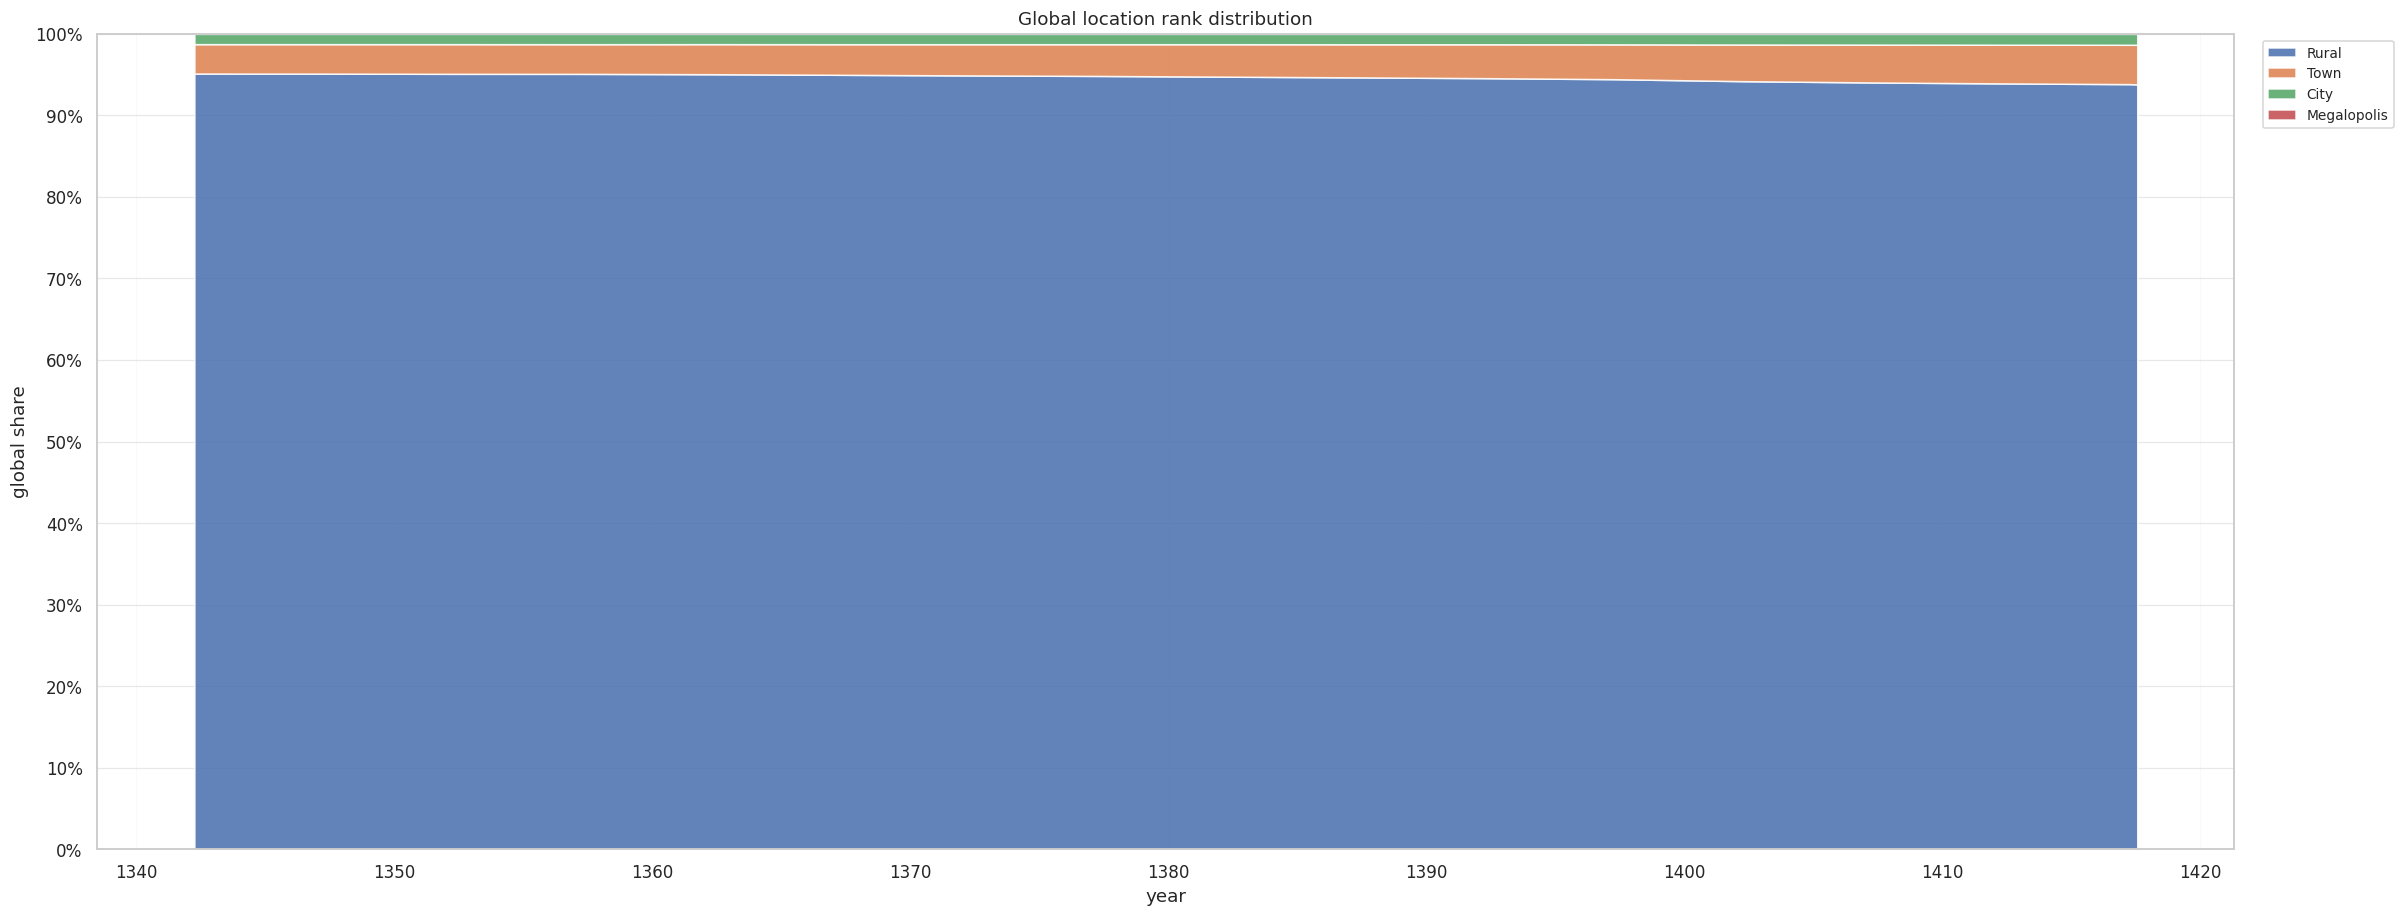

In [4]:
import matplotlib.pyplot as plt
import polars as pl
from IPython.display import display
from matplotlib.ticker import MaxNLocator, PercentFormatter

LOCATION_RANK_ORDER = ["rural_settlement", "town", "city", "megalopolis"]
LOCATION_RANK_LABELS = {
    "rural_settlement": "Rural",
    "town": "Town",
    "city": "City",
    "megalopolis": "Megalopolis",
}


def _selected_raw_locations() -> pl.LazyFrame:
    files = ds.fact_files("locations", playthrough_id=workbench.playthrough)
    if not files:
        return pl.DataFrame().lazy()
    frame = pl.scan_parquet(
        [str(path) for path in files],
        hive_partitioning=False,
        missing_columns="insert",
        extra_columns="ignore",
    )
    if START_DATE is not None:
        frame = frame.filter(pl.col("date_sort") >= int(START_DATE))
    if END_DATE is not None:
        frame = frame.filter(pl.col("date_sort") <= int(END_DATE))
    return frame.with_columns(
        (
            pl.col("year").cast(pl.Float64)
            + (pl.col("month").cast(pl.Float64) - 1.0) / 12.0
            + (pl.col("day").cast(pl.Float64) - 1.0) / 365.25
        ).alias("plot_year")
    )


def _plot_percent_stack(
    frame: pl.DataFrame,
    *,
    category: str,
    sort_col: str,
    title: str,
) -> None:
    if frame.is_empty() or not {"plot_year", "date_sort", category, "percent"}.issubset(frame.columns):
        print("No rows")
        return

    pivot = (
        frame.sort(["date_sort", sort_col])
        .pivot(
            index=["plot_year", "date_sort", "date"],
            on=category,
            values="percent",
            aggregate_function="first",
        )
        .sort("date_sort")
        .fill_null(0)
    )
    categories = [
        value
        for value in frame.sort(sort_col).get_column(category).unique(maintain_order=True).to_list()
        if value in pivot.columns
    ]
    if not categories:
        print("No rows")
        return

    x_values = pivot.get_column("plot_year").to_list()
    series = [pivot.get_column(value).to_list() for value in categories]
    fig, ax = plt.subplots(figsize=(22, 8.5))
    if len(x_values) == 1:
        bottom = 0.0
        for label, values in zip(categories, series, strict=True):
            value = values[0] if values else 0.0
            ax.bar(x_values[0], value, bottom=bottom, width=0.45, label=label)
            bottom += value
        ax.set_xlim(x_values[0] - 0.75, x_values[0] + 0.75)
    else:
        ax.stackplot(x_values, series, labels=categories, alpha=0.88)
    ax.set_ylim(0, 100)
    ax.set_yticks(list(range(0, 101, 10)))
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=100))
    ax.grid(axis="y", which="major", linewidth=0.8, alpha=0.45)
    ax.grid(axis="x", which="major", linewidth=0.4, alpha=0.18)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.set_title(title)
    ax.set_xlabel("year")
    ax.set_ylabel("global share")
    ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
    fig.tight_layout()
    display(fig, include=["image/png"])
    plt.close(fig)


locations_raw = _selected_raw_locations()
location_rank_categories = pl.DataFrame(
    {
        "rank": LOCATION_RANK_ORDER,
        "rank_label": [LOCATION_RANK_LABELS[value] for value in LOCATION_RANK_ORDER],
        "rank_sort": list(range(len(LOCATION_RANK_ORDER))),
    }
)
location_rank_counts = (
    locations_raw.filter(pl.col("rank").is_in(LOCATION_RANK_ORDER))
    .group_by(["snapshot_id", "date_sort", "year", "month", "day", "date", "plot_year", "rank"])
    .agg(pl.len().alias("locations"))
    .collect()
)
location_rank_snapshots = location_rank_counts.select(
    ["snapshot_id", "date_sort", "year", "month", "day", "date", "plot_year"]
).unique()
location_rank_distribution = (
    location_rank_snapshots.join(location_rank_categories, how="cross")
    .join(
        location_rank_counts,
        on=["snapshot_id", "date_sort", "year", "month", "day", "date", "plot_year", "rank"],
        how="left",
    )
    .with_columns(pl.col("locations").fill_null(0))
    .with_columns(pl.sum("locations").over("snapshot_id").alias("total_locations"))
    .with_columns(
        pl.when(pl.col("total_locations") > 0)
        .then(pl.col("locations") / pl.col("total_locations") * 100.0)
        .otherwise(0.0)
        .alias("percent")
    )
    .sort(["date_sort", "rank_sort"])
)

_plot_percent_stack(
    location_rank_distribution,
    category="rank_label",
    sort_col="rank_sort",
    title="Global location rank distribution",
)


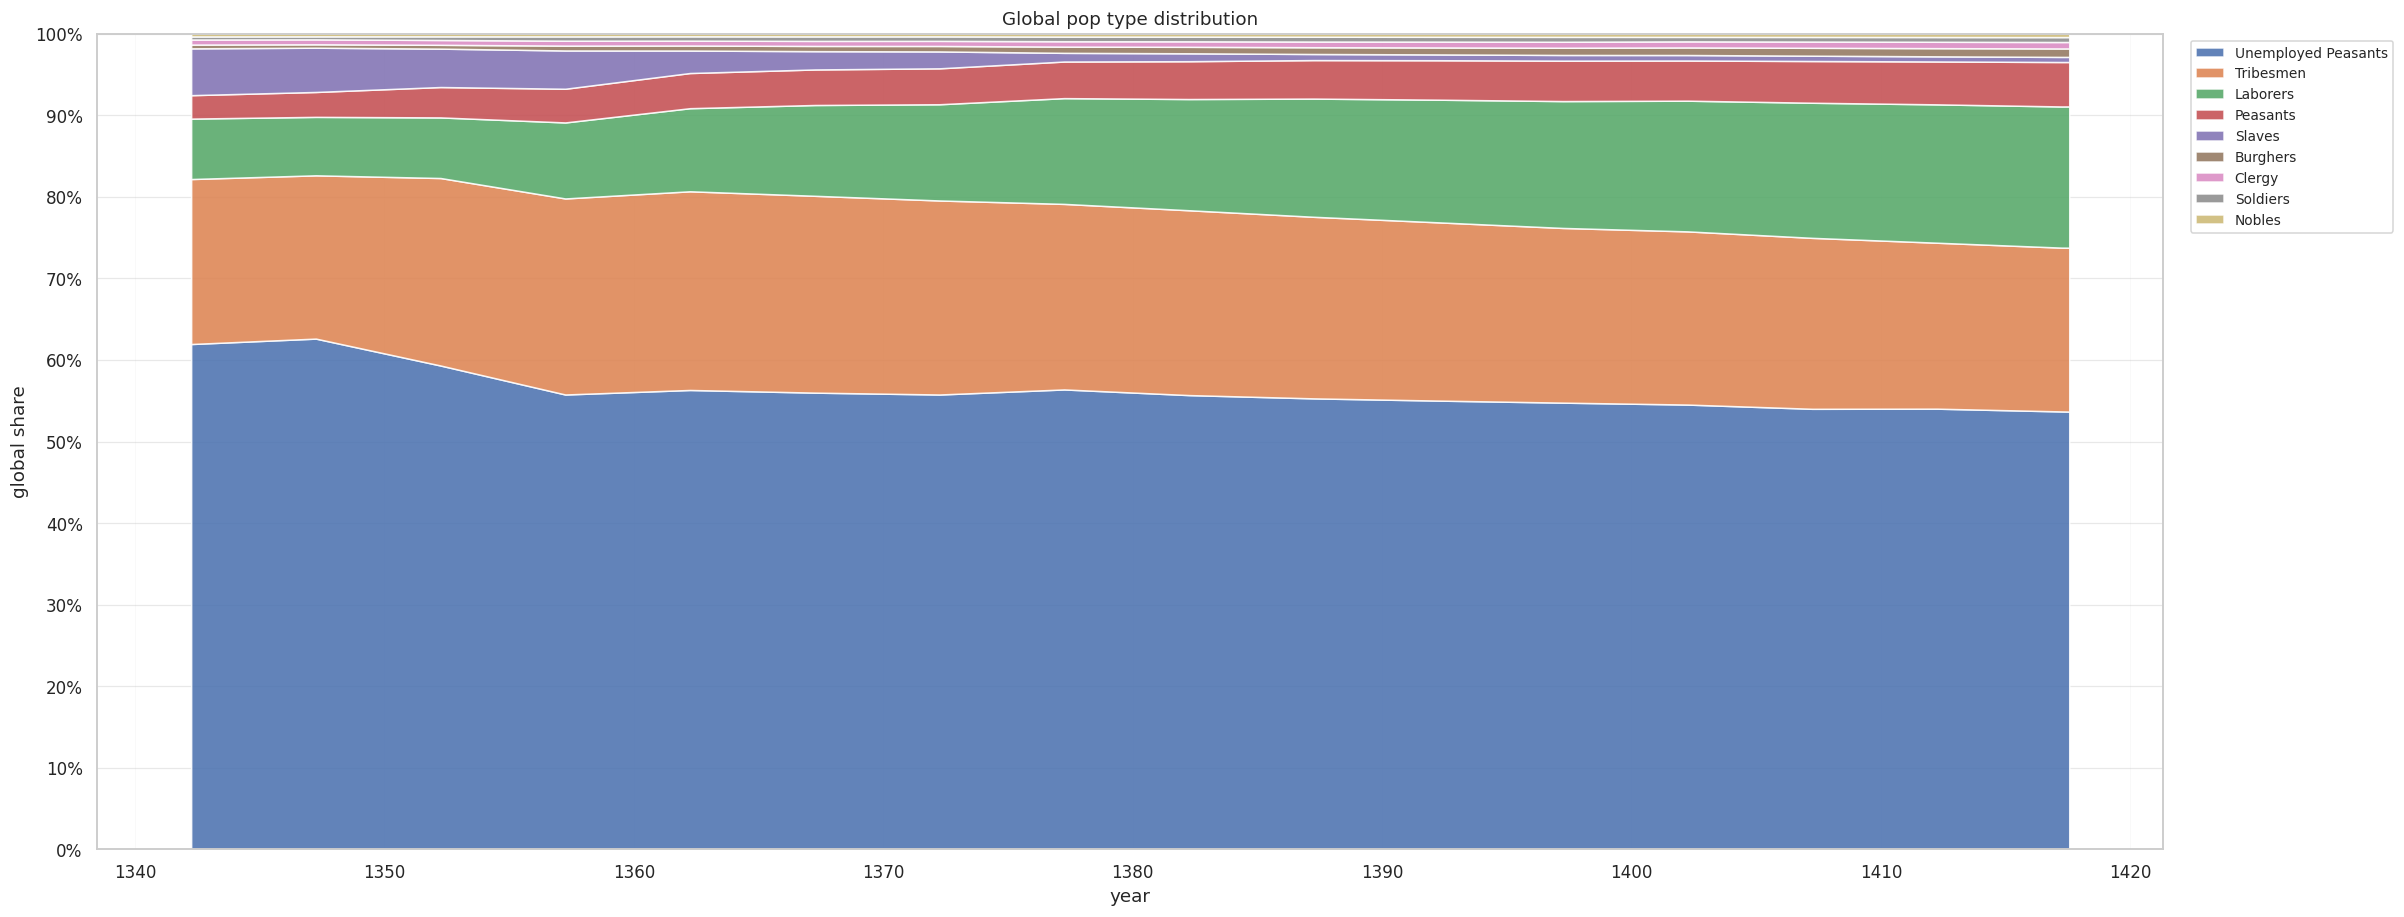

In [5]:
POP_TYPE_BASE_ORDER = [
    "nobles",
    "clergy",
    "burghers",
    "laborers",
    "soldiers",
    "peasants",
    "slaves",
    "tribesmen",
]
POP_TYPE_ORDER = [
    "nobles",
    "clergy",
    "burghers",
    "laborers",
    "soldiers",
    "peasants",
    "unemployed_peasants",
    "slaves",
    "tribesmen",
]
POP_TYPE_LABELS = {value: value.replace("_", " ").title() for value in POP_TYPE_ORDER}

locations_raw = _selected_raw_locations()
location_columns = set(locations_raw.collect_schema().names())
split_unemployed_peasants = {
    "population_peasants",
    "unemployed_peasants",
}.issubset(location_columns)
population_aggregations = [
    pl.sum(f"population_{pop_type}").alias(pop_type)
    for pop_type in POP_TYPE_BASE_ORDER
    if f"population_{pop_type}" in location_columns
]
if split_unemployed_peasants:
    population_aggregations.append(pl.sum("unemployed_peasants").alias("unemployed_peasants"))

if population_aggregations:
    pop_type_wide = (
        locations_raw.group_by(["snapshot_id", "date_sort", "year", "month", "day", "date", "plot_year"])
        .agg(population_aggregations)
        .sort("date_sort")
        .collect()
    )
    if split_unemployed_peasants:
        pop_type_wide = pop_type_wide.with_columns(
            pl.max_horizontal(
                pl.col("peasants") - pl.col("unemployed_peasants"),
                pl.lit(0.0),
            ).alias("peasants")
        )
    population_columns = [pop_type for pop_type in POP_TYPE_ORDER if pop_type in pop_type_wide.columns]
    pop_type_distribution = (
        pop_type_wide.unpivot(
            index=["snapshot_id", "date_sort", "year", "month", "day", "date", "plot_year"],
            on=population_columns,
            variable_name="pop_type",
            value_name="population",
        )
        .with_columns(
            pl.col("pop_type").replace_strict(POP_TYPE_LABELS, default=pl.col("pop_type")).alias("pop_type_label"),
        )
        .with_columns(pl.sum("population").over("snapshot_id").alias("total_population"))
        .with_columns(
            pl.when(pl.col("total_population") > 0)
            .then(pl.col("population") / pl.col("total_population") * 100.0)
            .otherwise(0.0)
            .alias("percent")
        )
    )
    pop_type_size_order = (
        pop_type_distribution.group_by("pop_type")
        .agg(pl.sum("population").alias("sort_population"))
        .sort(["sort_population", "pop_type"], descending=[True, False])
        .with_row_index("pop_type_sort")
        .select(["pop_type", "pop_type_sort"])
    )
    pop_type_distribution = (
        pop_type_distribution.join(pop_type_size_order, on="pop_type", how="left")
        .sort(["date_sort", "pop_type_sort"])
    )
else:
    pop_type_distribution = pl.DataFrame()

_plot_percent_stack(
    pop_type_distribution,
    category="pop_type_label",
    sort_col="pop_type_sort",
    title="Global pop type distribution",
)


## Population / Locations Over Time

In [6]:
population = workbench.population()
population_latest = population.latest
population_delta = population.delta
population_ts = population.time_series
population_ts_top = population.top_time_series
population_global = population.global_time_series


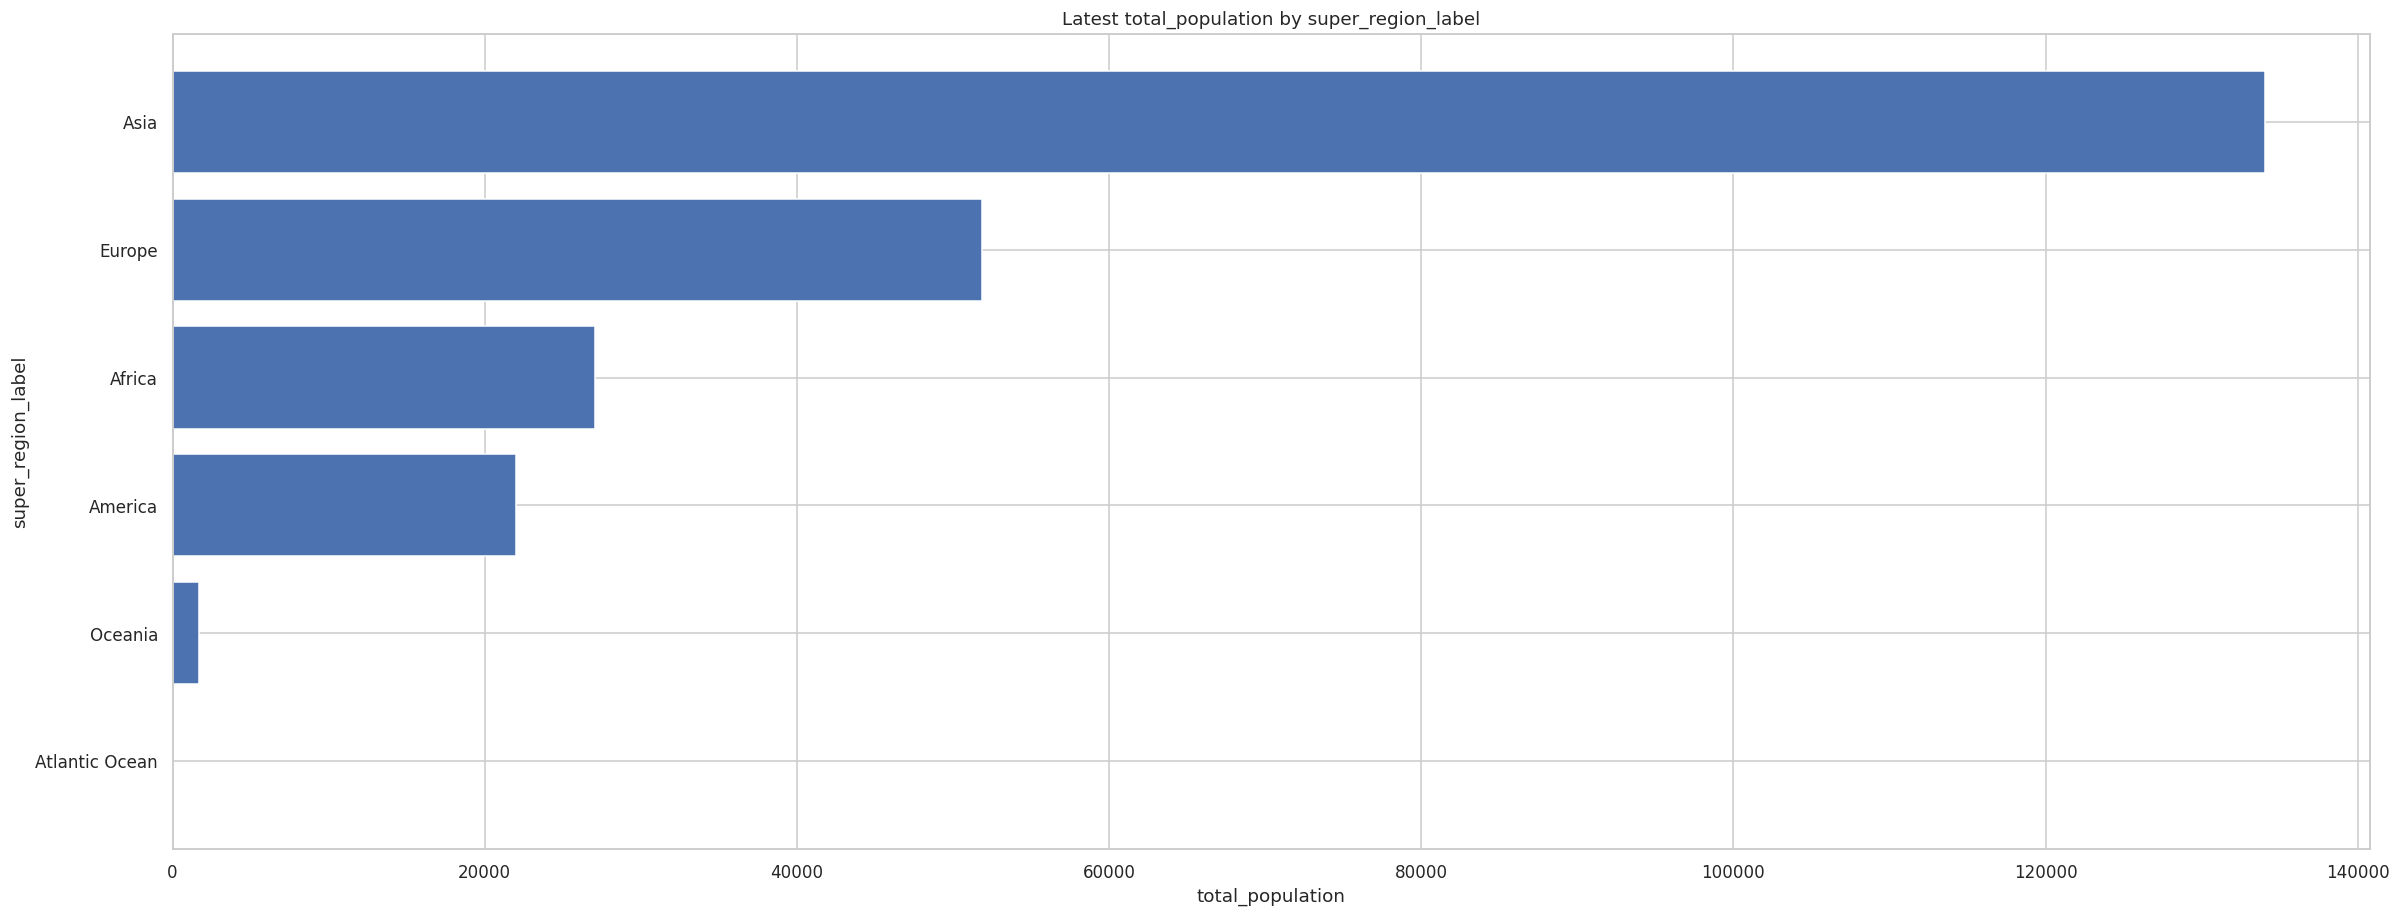

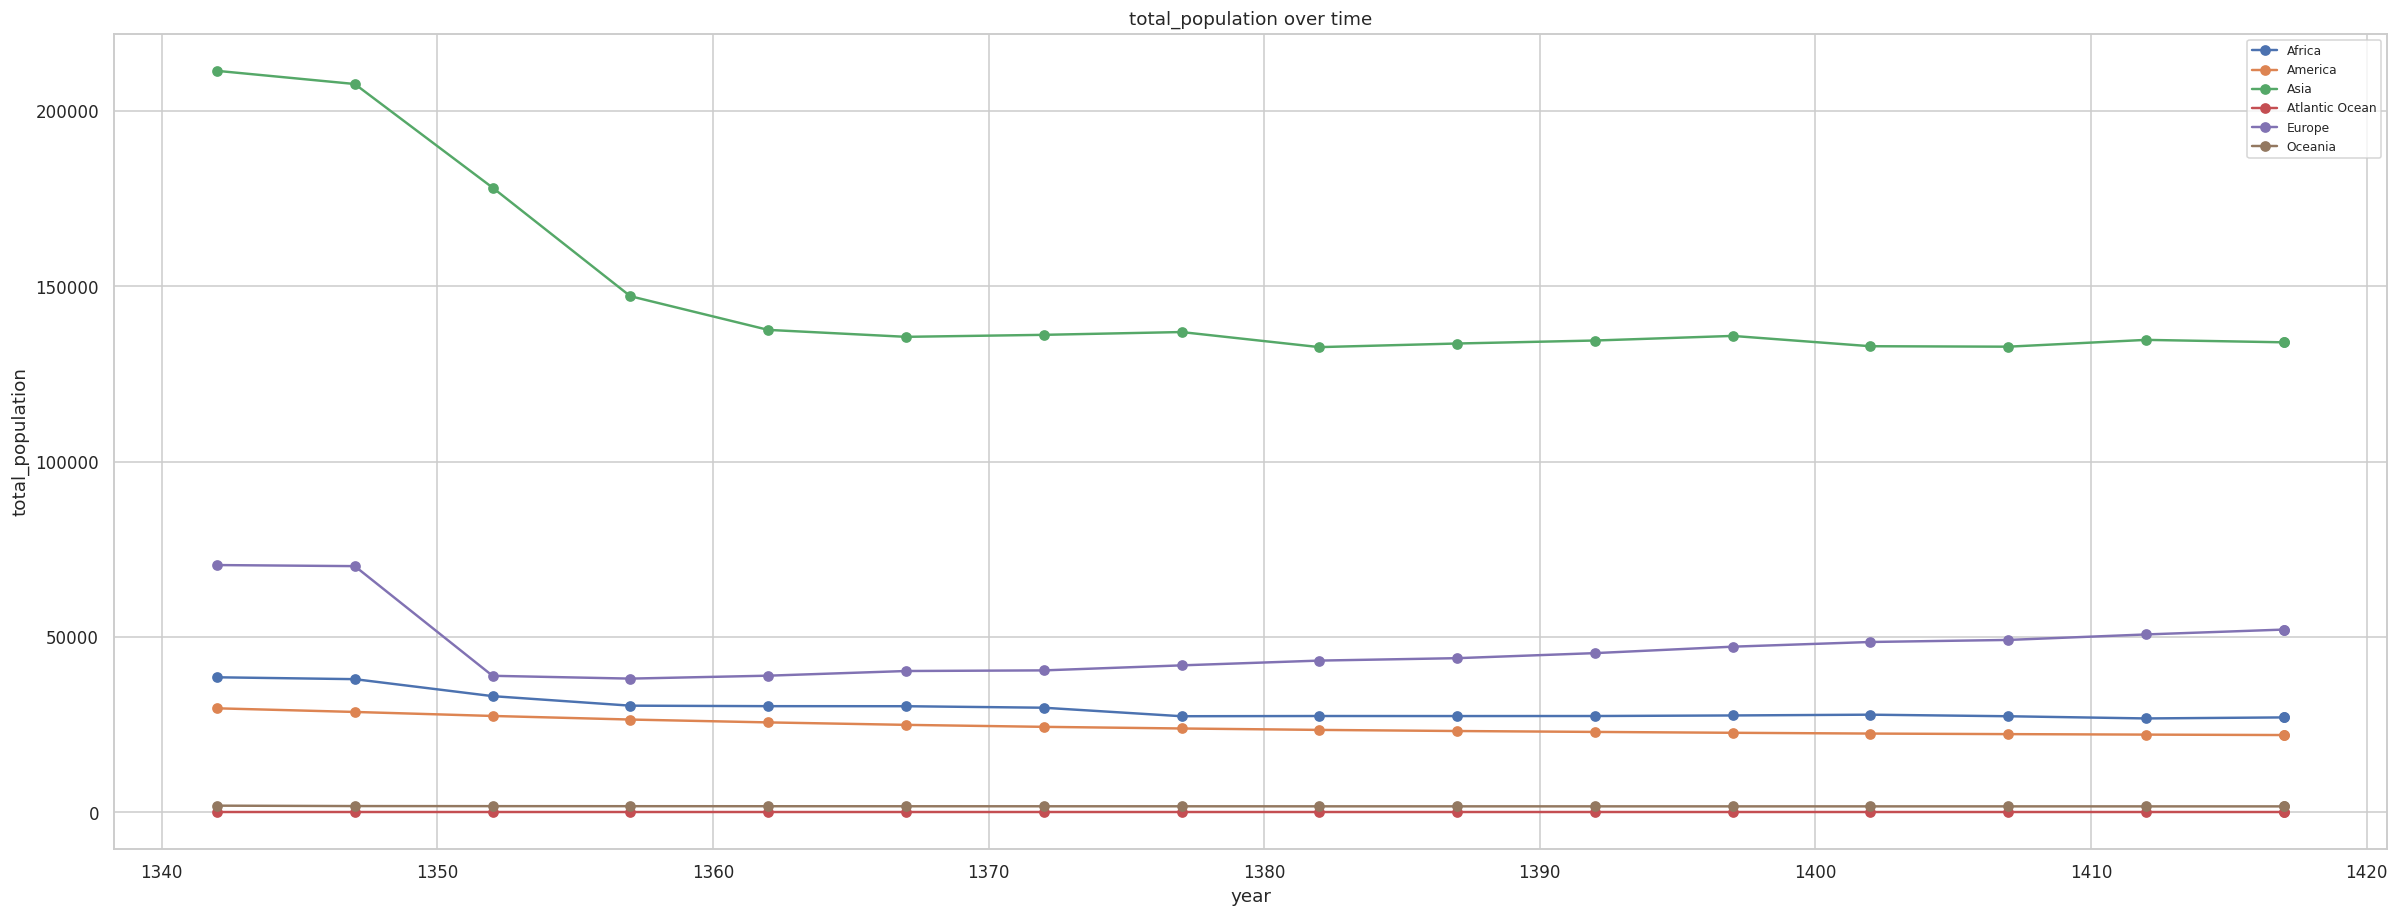

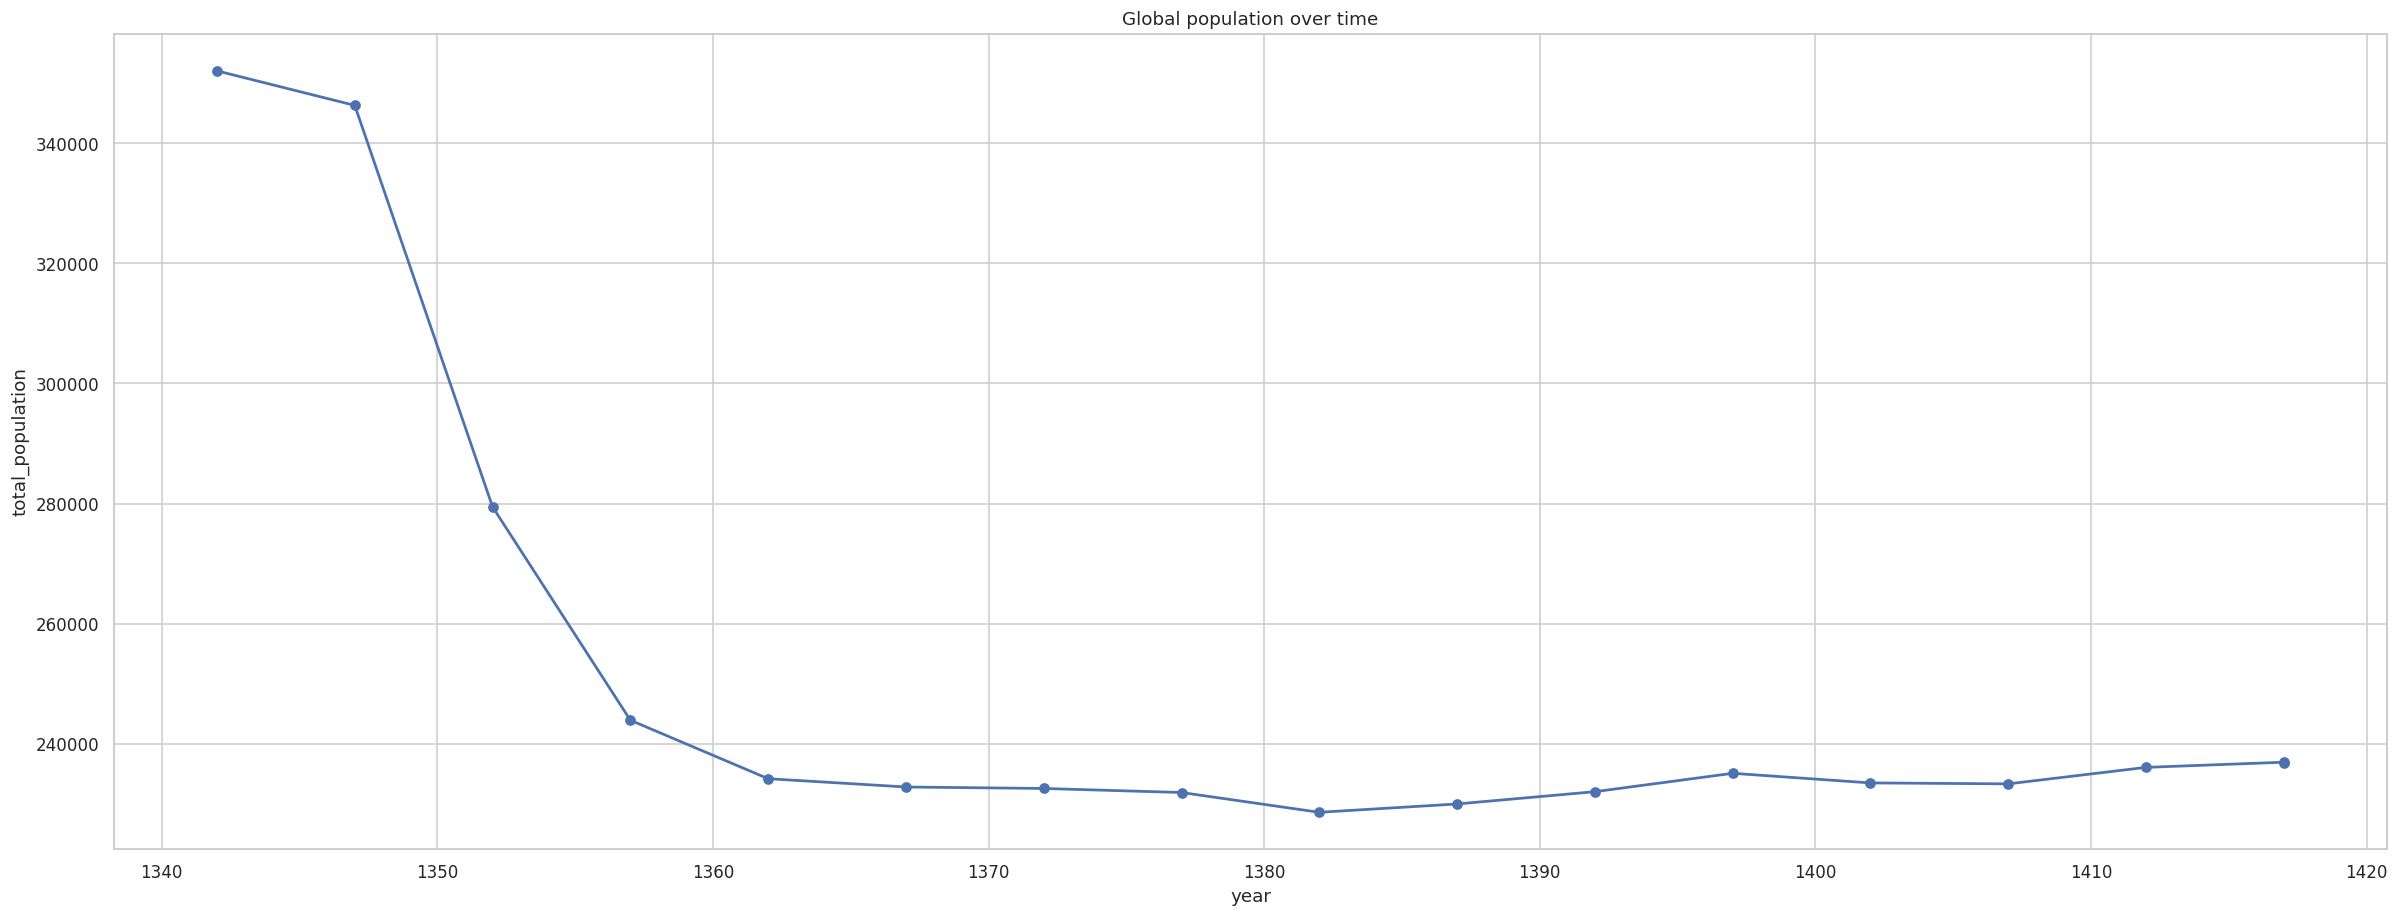

In [7]:
workbench.plot_population(population)


## Global Buildings Over Time

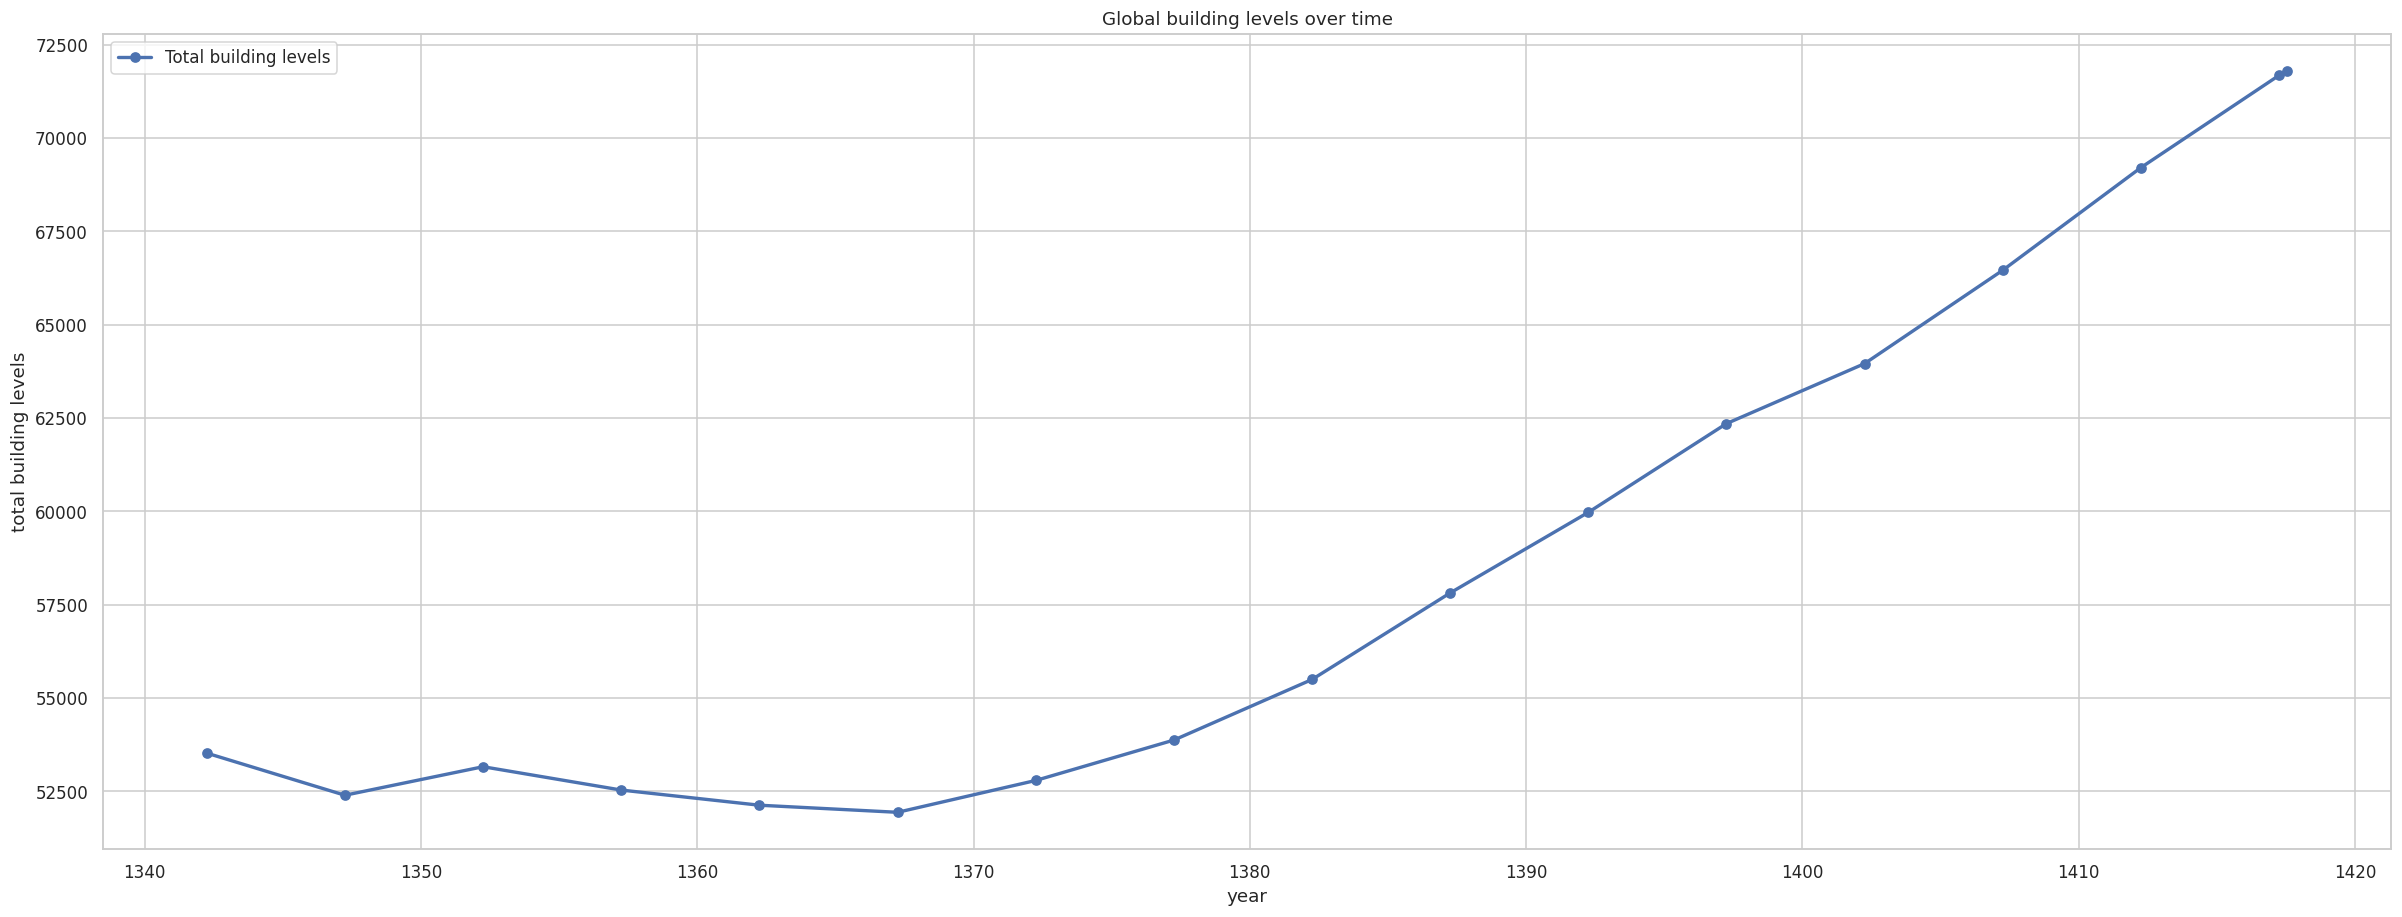

In [8]:
import matplotlib.pyplot as plt
import polars as pl
from IPython.display import display
from matplotlib.ticker import MaxNLocator


def _selected_raw_global_buildings() -> pl.LazyFrame:
    files = ds.fact_files("buildings", playthrough_id=workbench.playthrough)
    if not files:
        return pl.DataFrame(
            schema={
                "snapshot_id": pl.String,
                "date_sort": pl.Int64,
                "year": pl.Int64,
                "month": pl.Int64,
                "day": pl.Int64,
                "date": pl.String,
                "level": pl.Float64,
            }
        ).lazy()
    frame = pl.scan_parquet(
        [str(path) for path in files],
        hive_partitioning=False,
        missing_columns="insert",
        extra_columns="ignore",
    )
    if START_DATE is not None:
        frame = frame.filter(pl.col("date_sort") >= int(START_DATE))
    if END_DATE is not None:
        frame = frame.filter(pl.col("date_sort") <= int(END_DATE))
    return frame.with_columns(
        (
            pl.col("year").cast(pl.Float64)
            + (pl.col("month").cast(pl.Float64) - 1.0) / 12.0
            + (pl.col("day").cast(pl.Float64) - 1.0) / 365.25
        ).alias("plot_year")
    )


global_buildings_ts = (
    _selected_raw_global_buildings()
    .group_by(["snapshot_id", "date_sort", "year", "month", "day", "date", "plot_year"])
    .agg(
        pl.sum("level").alias("total_building_levels"),
        pl.len().alias("building_records"),
    )
    .sort("date_sort")
    .collect()
)

if global_buildings_ts.is_empty():
    print("No building rows")
else:
    fig, ax = plt.subplots(figsize=NOTEBOOK_FIGSIZE)
    ax.plot(
        global_buildings_ts["plot_year"].to_list(),
        global_buildings_ts["total_building_levels"].to_list(),
        marker="o",
        linewidth=2.2,
        label="Total building levels",
    )
    ax.set_title("Global building levels over time")
    ax.set_xlabel("year")
    ax.set_ylabel("total building levels")
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.legend(loc="best")
    fig.tight_layout()
    display(fig, include=["image/png"])
    plt.close(fig)


## Infrastructure Buildings Over Time


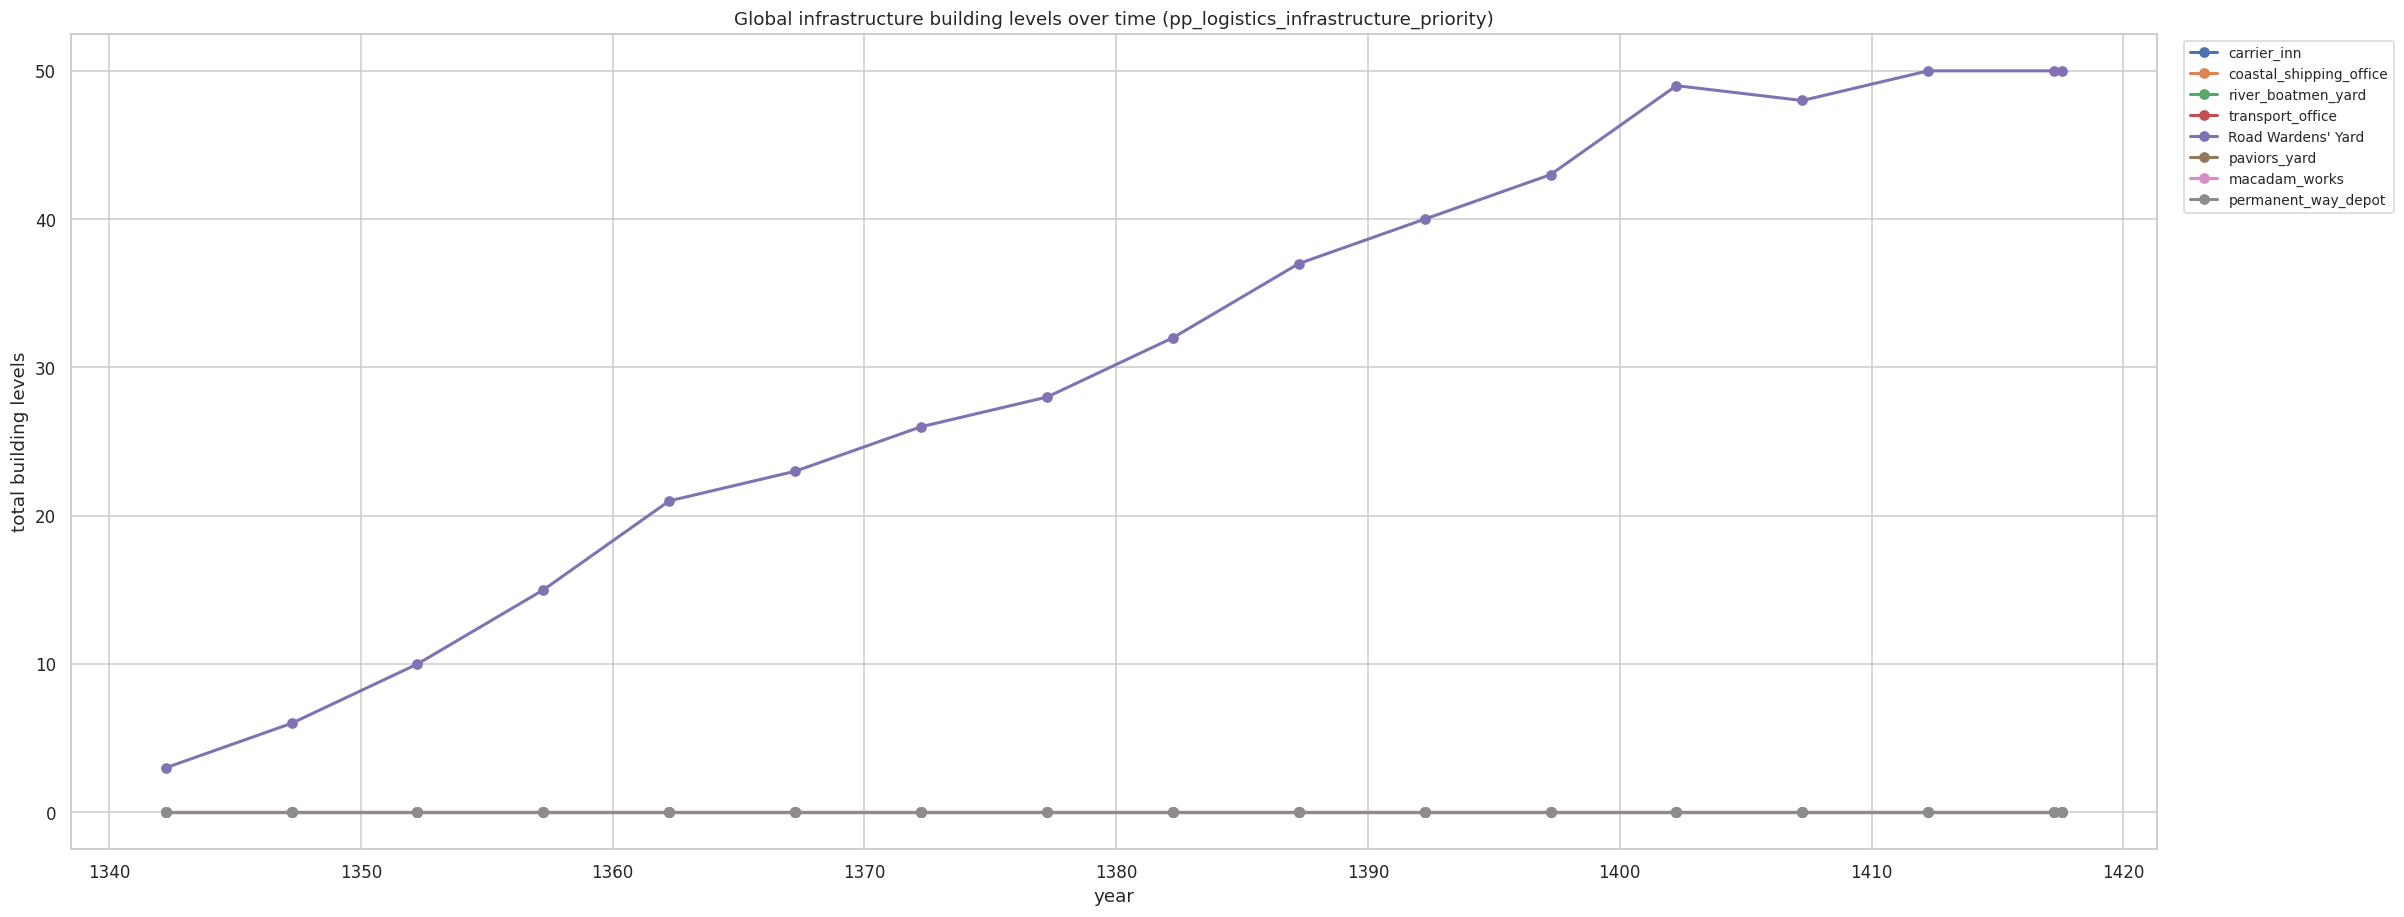

building_type,building_label,total_building_levels,building_records
str,str,f64,i64
"""carrier_inn""","""carrier_inn""",0.0,0
"""coastal_shipping_office""","""coastal_shipping_office""",0.0,0
"""river_boatmen_yard""","""river_boatmen_yard""",0.0,0
"""transport_office""","""transport_office""",0.0,0
"""road_wardens_yard""","""Road Wardens' Yard""",50.0,51
"""paviors_yard""","""paviors_yard""",0.0,0
"""macadam_works""","""macadam_works""",0.0,0
"""permanent_way_depot""","""permanent_way_depot""",0.0,0


In [9]:
import matplotlib.pyplot as plt
import polars as pl
from IPython.display import display
from matplotlib.ticker import MaxNLocator

from eu5gameparser.clausewitz.syntax import CList
from eu5gameparser.load_order import load_merged_directory, load_profile

INFRASTRUCTURE_BUILDING_TAG = "pp_logistics_infrastructure_priority"
INFRASTRUCTURE_BUILDING_ORDER = [
    "carrier_inn",
    "coastal_shipping_office",
    "river_boatmen_yard",
    "transport_office",
    "road_wardens_yard",
    "paviors_yard",
    "macadam_works",
    "permanent_way_depot",
]


def _infrastructure_tag_values(value: object) -> list[str]:
    if isinstance(value, CList):
        return [str(item) for item in value.items]
    if value is None:
        return []
    return [str(value)]


def _building_types_for_custom_tag(tag: str, fallback_order: list[str]) -> list[str]:
    if ds.profile is None:
        return fallback_order
    try:
        profile = load_profile(ds.profile, ds.load_order_path)
        merged = load_merged_directory(profile, "building_types")
    except (FileNotFoundError, KeyError, OSError, pl.exceptions.PolarsError) as exc:
        print(f"Could not load building tag {tag!r}; using fallback list: {exc}")
        return fallback_order

    tagged: list[str] = []
    for entry in merged.entries:
        tags: list[str] = []
        if isinstance(entry.value, CList):
            for value in entry.value.values("custom_tags"):
                tags.extend(_infrastructure_tag_values(value))
        if tag in set(tags):
            tagged.append(entry.key)

    if not tagged:
        print(f"No buildings found for tag {tag!r}; using fallback list.")
        return fallback_order

    sort_order = {building_type: index for index, building_type in enumerate(fallback_order)}
    return sorted(tagged, key=lambda building_type: (sort_order.get(building_type, len(sort_order)), building_type))


def _selected_infrastructure_snapshots() -> pl.DataFrame:
    frame = snapshots.filter(pl.col("playthrough_id") == workbench.playthrough)
    if START_DATE is not None:
        frame = frame.filter(pl.col("date_sort") >= int(START_DATE))
    if END_DATE is not None:
        frame = frame.filter(pl.col("date_sort") <= int(END_DATE))
    return (
        frame.with_columns(
            (
                pl.col("year").cast(pl.Float64)
                + (pl.col("month").cast(pl.Float64) - 1.0) / 12.0
                + (pl.col("day").cast(pl.Float64) - 1.0) / 365.25
            ).alias("plot_year")
        )
        .select(["snapshot_id", "date_sort", "year", "month", "day", "date", "plot_year"])
        .sort("date_sort")
    )


def _selected_raw_infrastructure_buildings(building_types: list[str]) -> pl.LazyFrame:
    schema = {
        "snapshot_id": pl.String,
        "date_sort": pl.Int64,
        "year": pl.Int64,
        "month": pl.Int64,
        "day": pl.Int64,
        "date": pl.String,
        "building_type": pl.String,
        "level": pl.Float64,
    }
    files = ds.fact_files("buildings", playthrough_id=workbench.playthrough)
    if not files or not building_types:
        return pl.DataFrame(schema=schema).lazy()

    frame = pl.scan_parquet(
        [str(path) for path in files],
        hive_partitioning=False,
        missing_columns="insert",
        extra_columns="ignore",
    )
    if START_DATE is not None:
        frame = frame.filter(pl.col("date_sort") >= int(START_DATE))
    if END_DATE is not None:
        frame = frame.filter(pl.col("date_sort") <= int(END_DATE))
    return frame.filter(pl.col("building_type").is_in(building_types)).select(list(schema))


infrastructure_building_types = _building_types_for_custom_tag(
    INFRASTRUCTURE_BUILDING_TAG,
    INFRASTRUCTURE_BUILDING_ORDER,
)
infrastructure_building_lookup = pl.DataFrame(
    {
        "building_type": infrastructure_building_types,
        "building_sort": list(range(len(infrastructure_building_types))),
    },
    schema={"building_type": pl.String, "building_sort": pl.Int64},
)
infrastructure_buildings = (
    infrastructure_building_lookup.join(
        ds.dim("building_types").select(["building_type", "building_label"]),
        on="building_type",
        how="left",
    )
    .with_columns(pl.coalesce(pl.col("building_label"), pl.col("building_type")).alias("building_label"))
    .sort("building_sort")
)

infrastructure_buildings_agg = (
    _selected_raw_infrastructure_buildings(infrastructure_building_types)
    .group_by(["snapshot_id", "date_sort", "year", "month", "day", "date", "building_type"])
    .agg(
        pl.sum("level").alias("total_building_levels"),
        pl.len().alias("building_records"),
    )
    .collect()
)
infrastructure_snapshots = _selected_infrastructure_snapshots()

if infrastructure_buildings.is_empty() or infrastructure_snapshots.is_empty():
    infrastructure_buildings_ts = pl.DataFrame()
    infrastructure_building_latest = pl.DataFrame()
    print("No infrastructure building rows")
else:
    infrastructure_buildings_ts = (
        infrastructure_snapshots.join(infrastructure_buildings, how="cross")
        .join(
            infrastructure_buildings_agg,
            on=["snapshot_id", "date_sort", "year", "month", "day", "date", "building_type"],
            how="left",
        )
        .with_columns(
            pl.col("total_building_levels").fill_null(0.0),
            pl.col("building_records").fill_null(0).cast(pl.Int64),
        )
        .sort(["building_sort", "date_sort"])
    )
    latest_date = infrastructure_buildings_ts.get_column("date_sort").max()
    infrastructure_building_latest = (
        infrastructure_buildings_ts.filter(pl.col("date_sort") == latest_date)
        .sort("building_sort")
        .select(["building_type", "building_label", "total_building_levels", "building_records"])
    )

    fig, ax = plt.subplots(figsize=NOTEBOOK_FIGSIZE)
    for row in infrastructure_buildings.iter_rows(named=True):
        series = infrastructure_buildings_ts.filter(pl.col("building_type") == row["building_type"]).sort("date_sort")
        ax.plot(
            series["plot_year"].to_list(),
            series["total_building_levels"].to_list(),
            marker="o",
            linewidth=2.0,
            label=row["building_label"],
        )
    ax.set_title(f"Global infrastructure building levels over time ({INFRASTRUCTURE_BUILDING_TAG})")
    ax.set_xlabel("year")
    ax.set_ylabel("total building levels")
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
    fig.tight_layout()
    display(fig, include=["image/png"])
    plt.close(fig)
    display(infrastructure_building_latest)




## Goods And Markets

In [10]:
goods = workbench.goods()
goods_global_ts = goods.global_time_series
market_scarcity = goods.scarcity
goods_imbalance = goods.imbalance
goods_imbalance_all = goods.goods_imbalance_all
market_flow_value = goods.flow_value


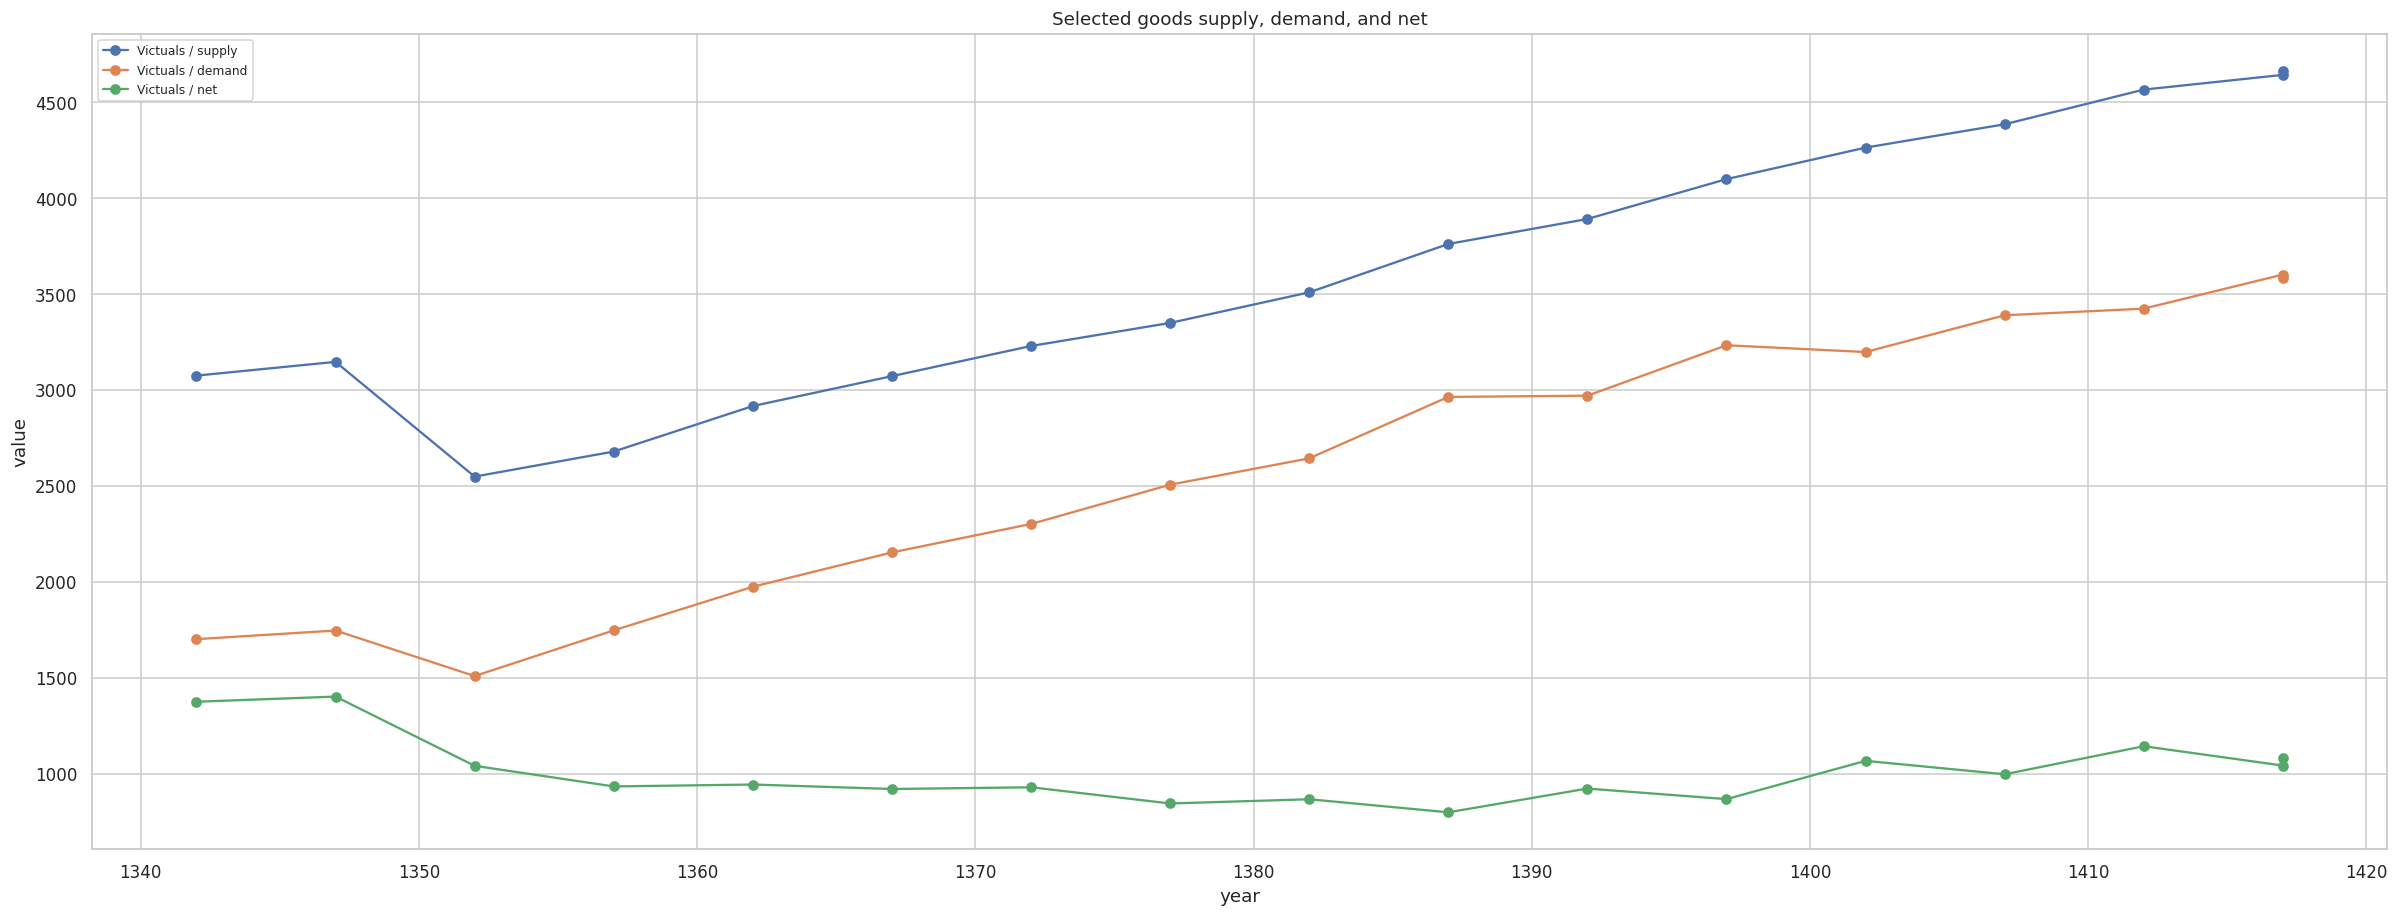

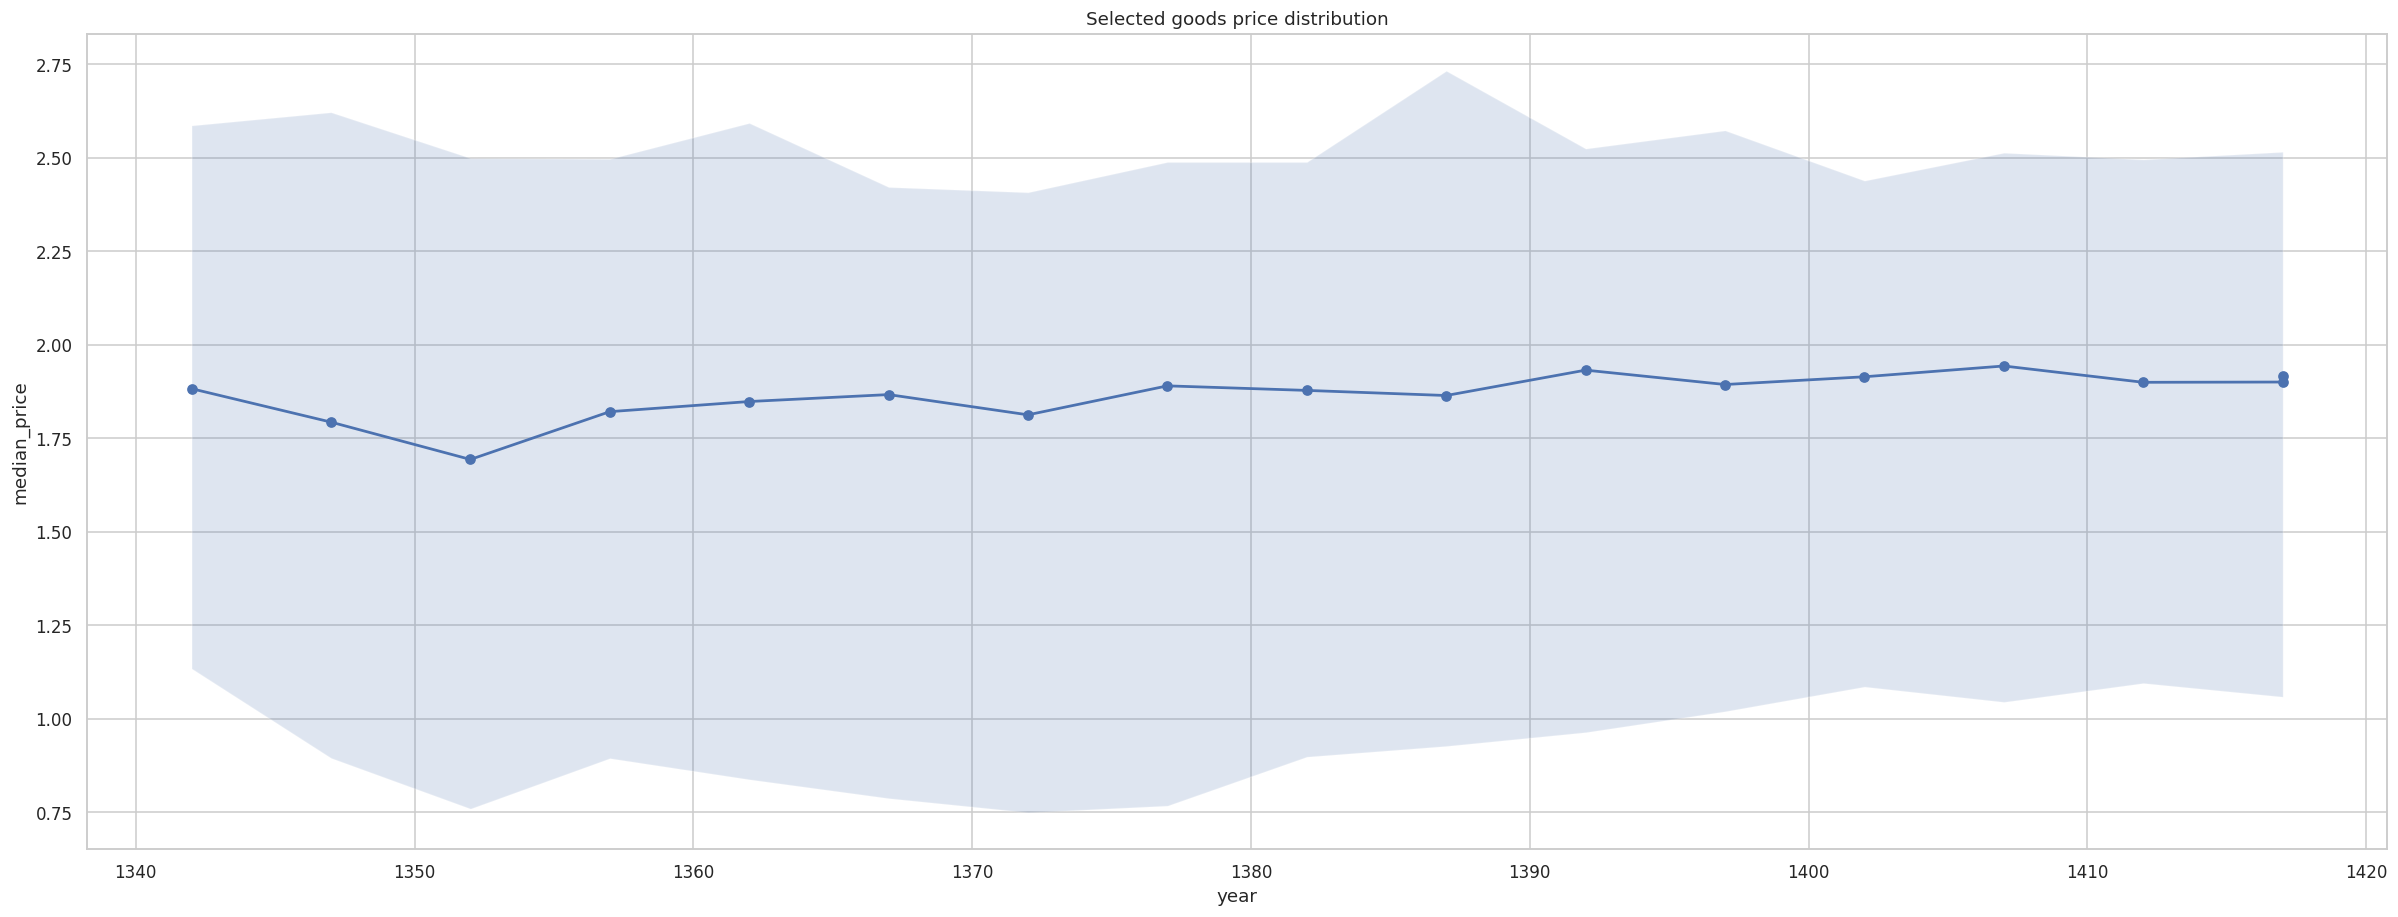

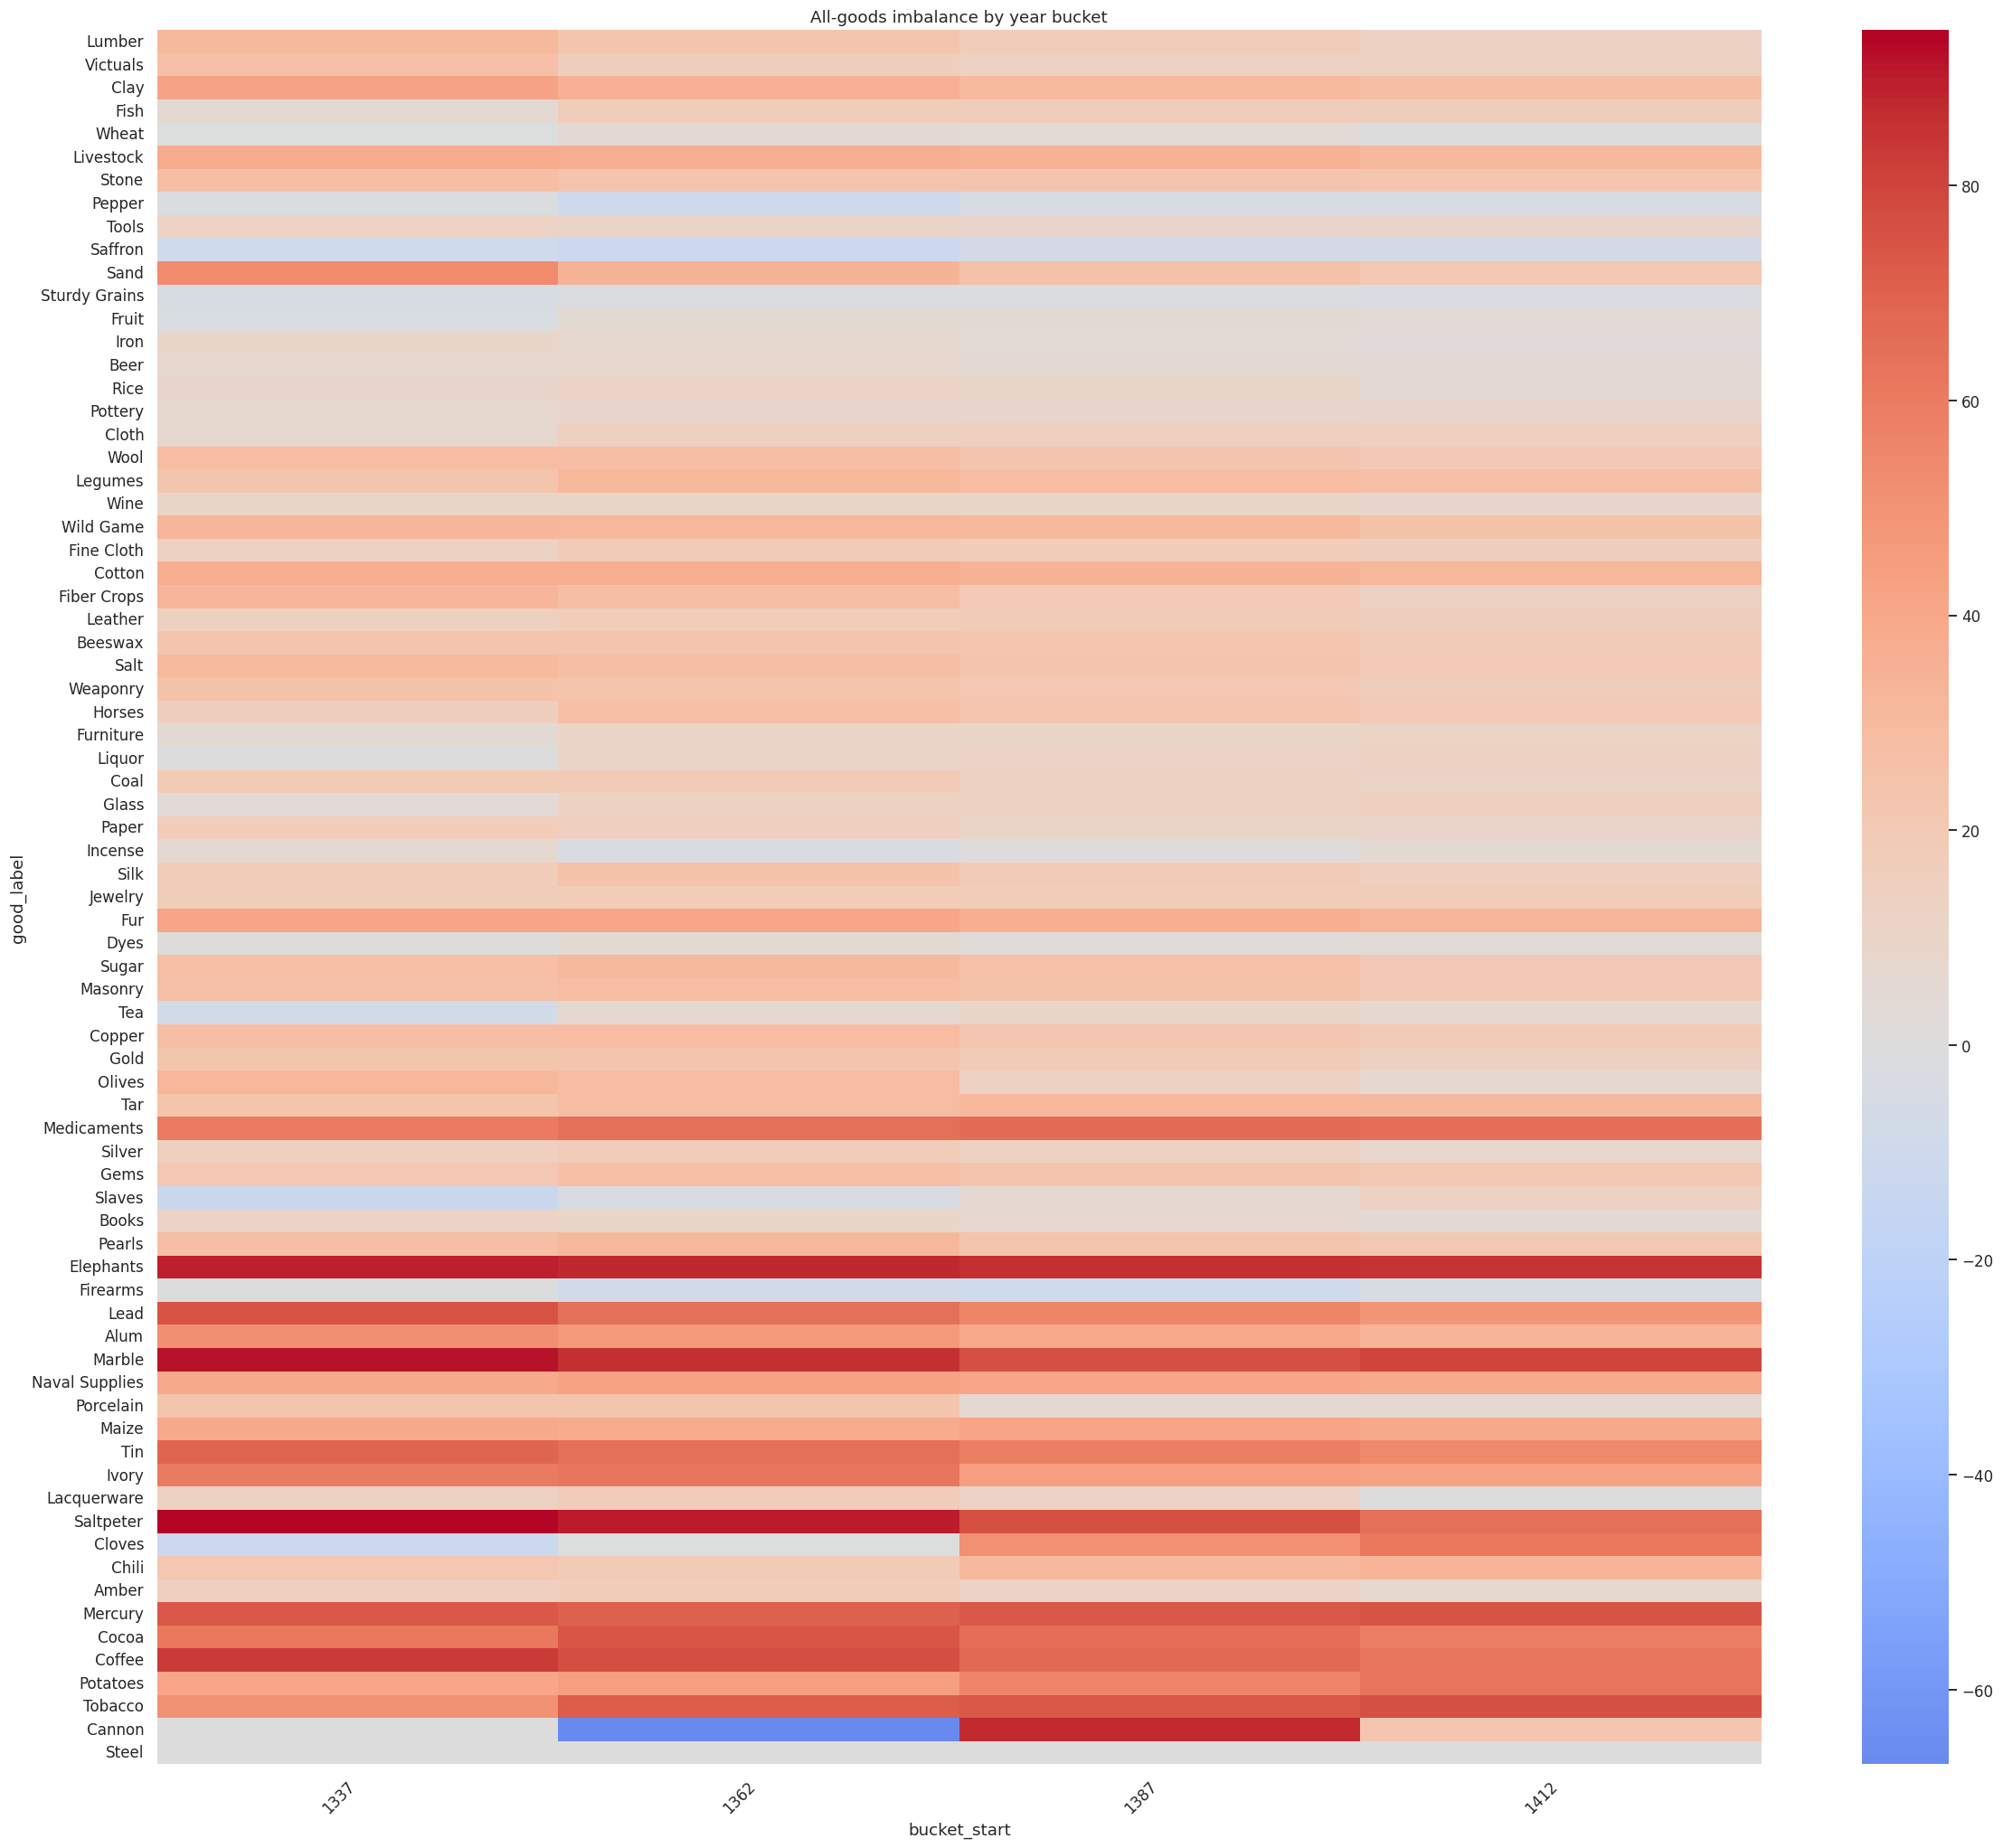

In [11]:
workbench.plot_goods(goods)


## Goods Source / Sink Flows

In [12]:
flows = workbench.flows()
source_breakdown = flows.source_breakdown
sink_breakdown = flows.sink_breakdown
source_ts = flows.source_time_series
sink_ts = flows.sink_time_series
good_consumption_latest = flows.good_consumption_latest
good_consumption_over_time = flows.good_consumption_over_time


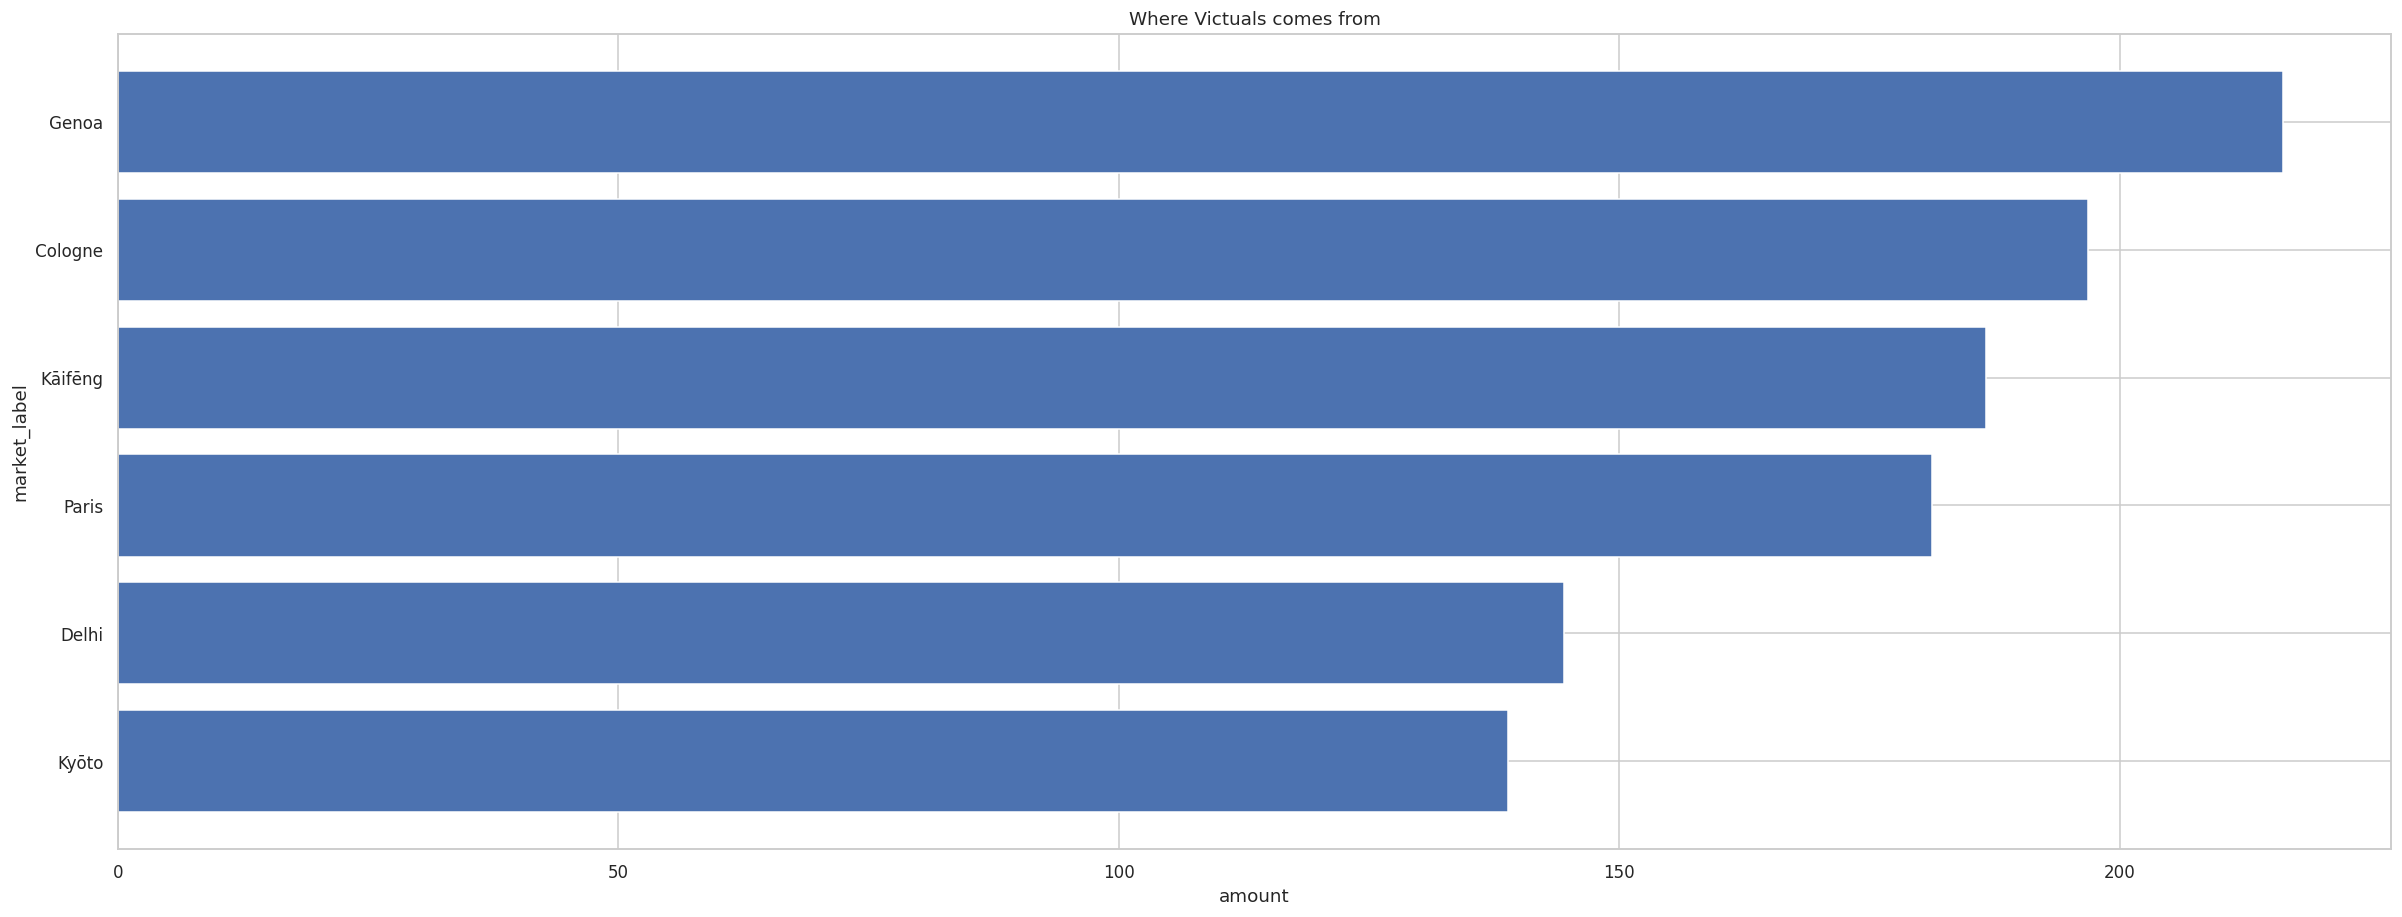

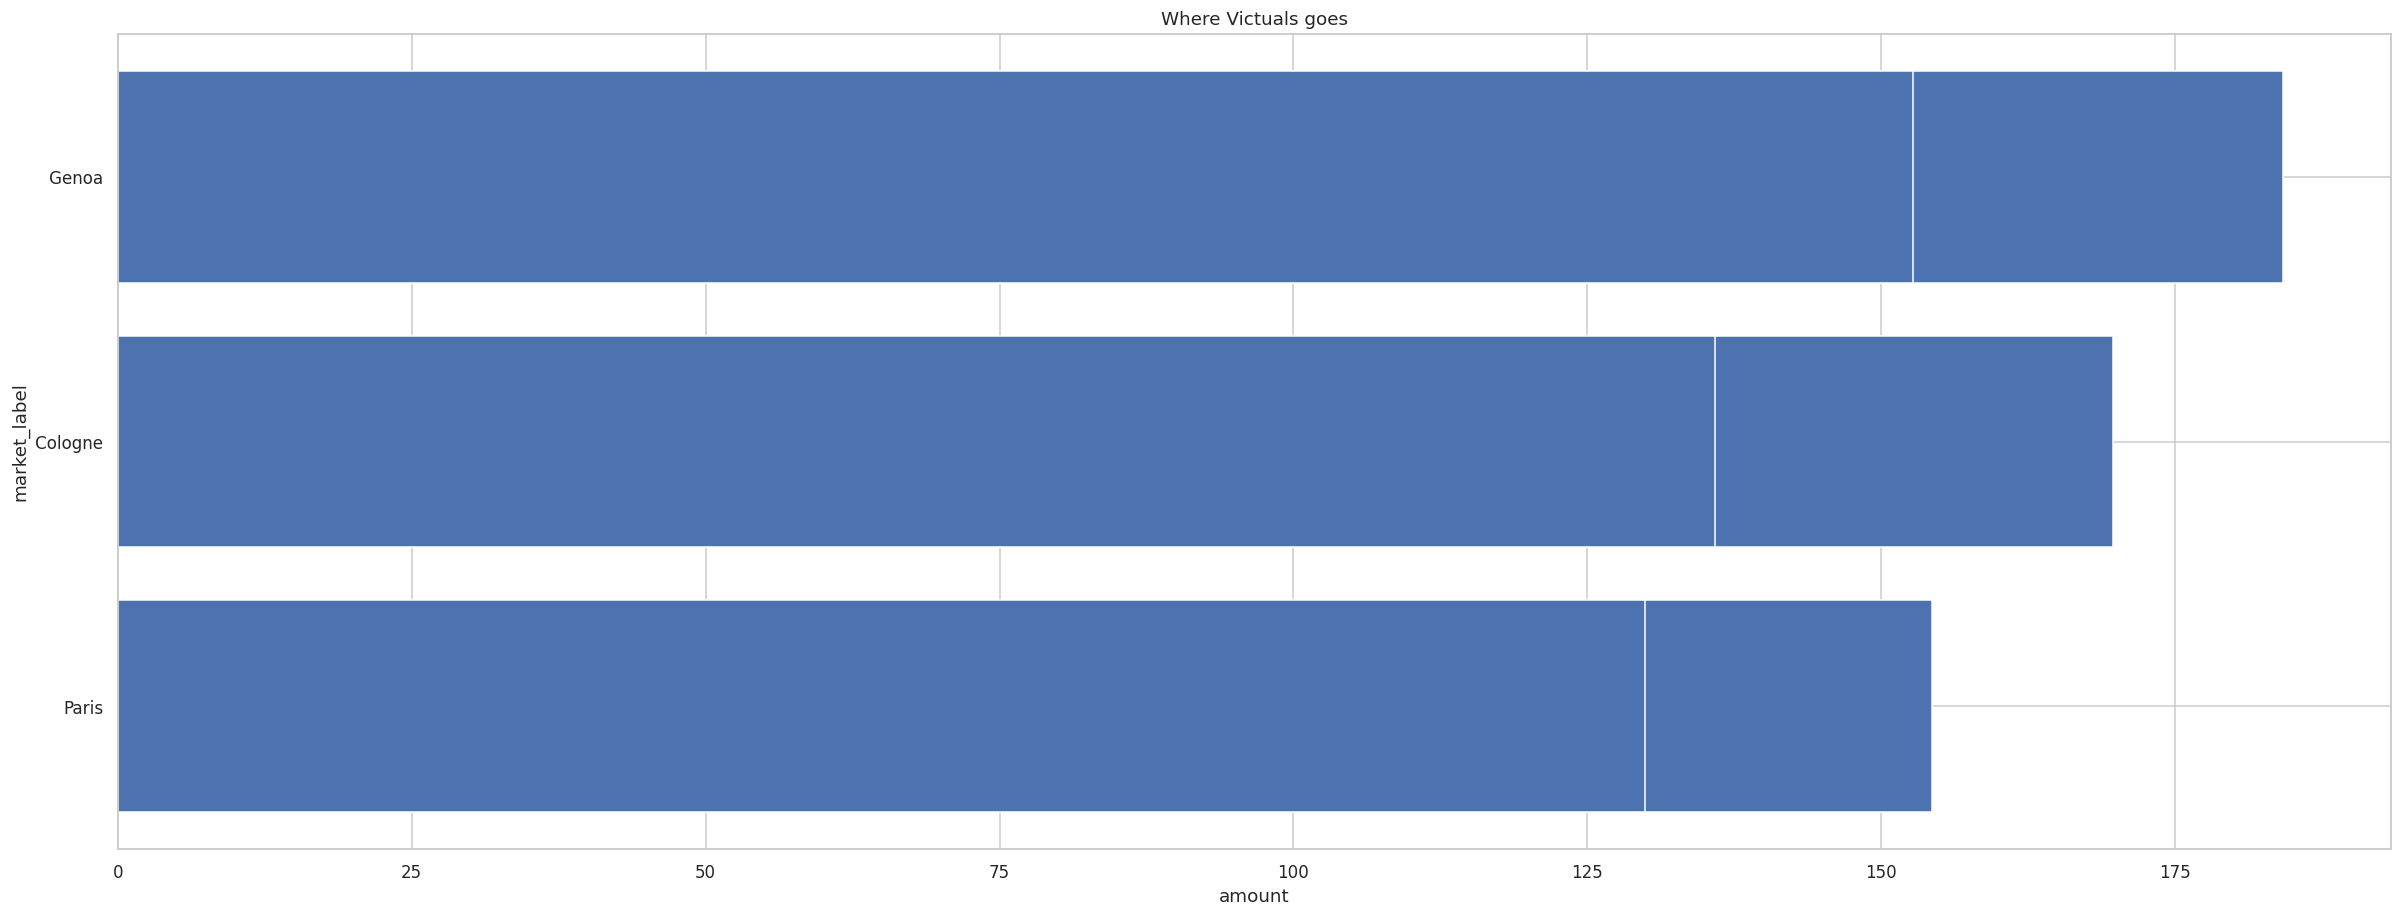

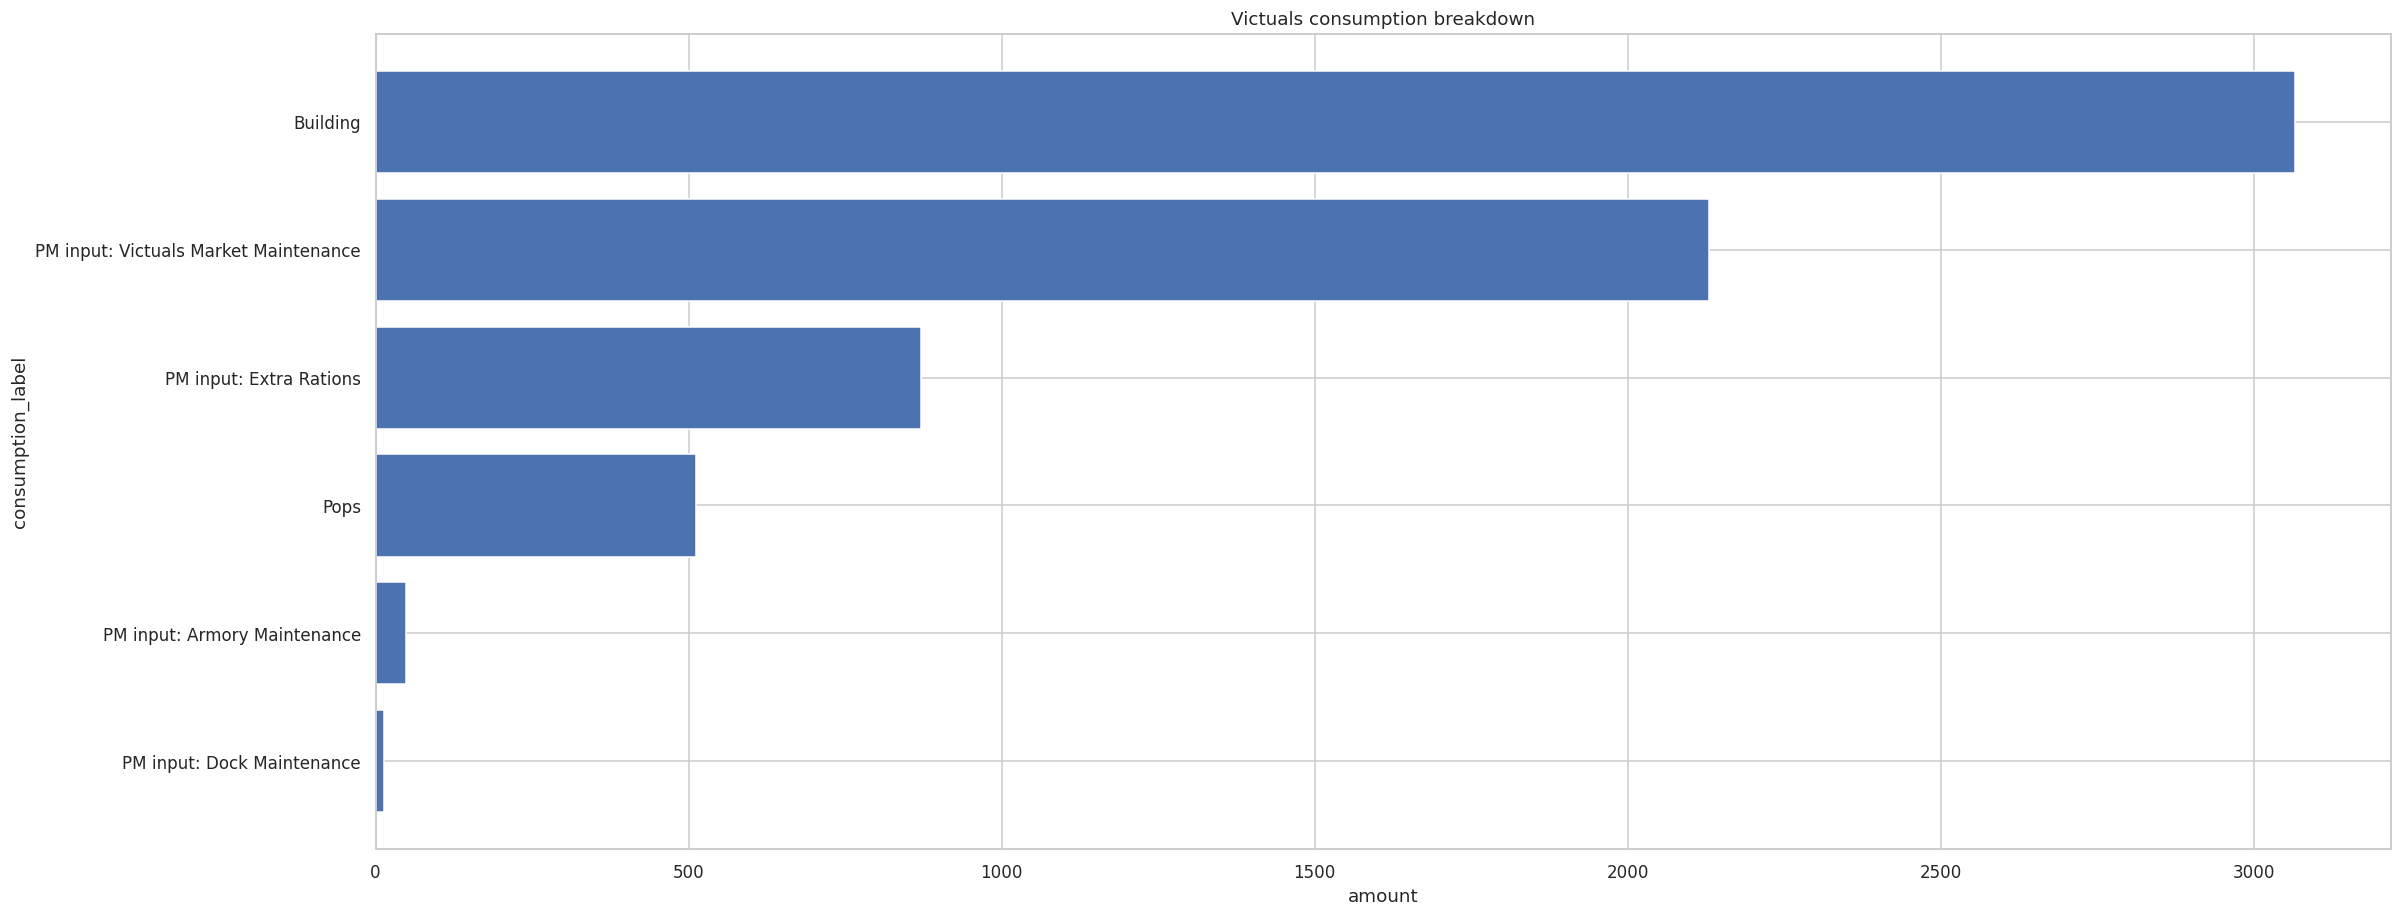

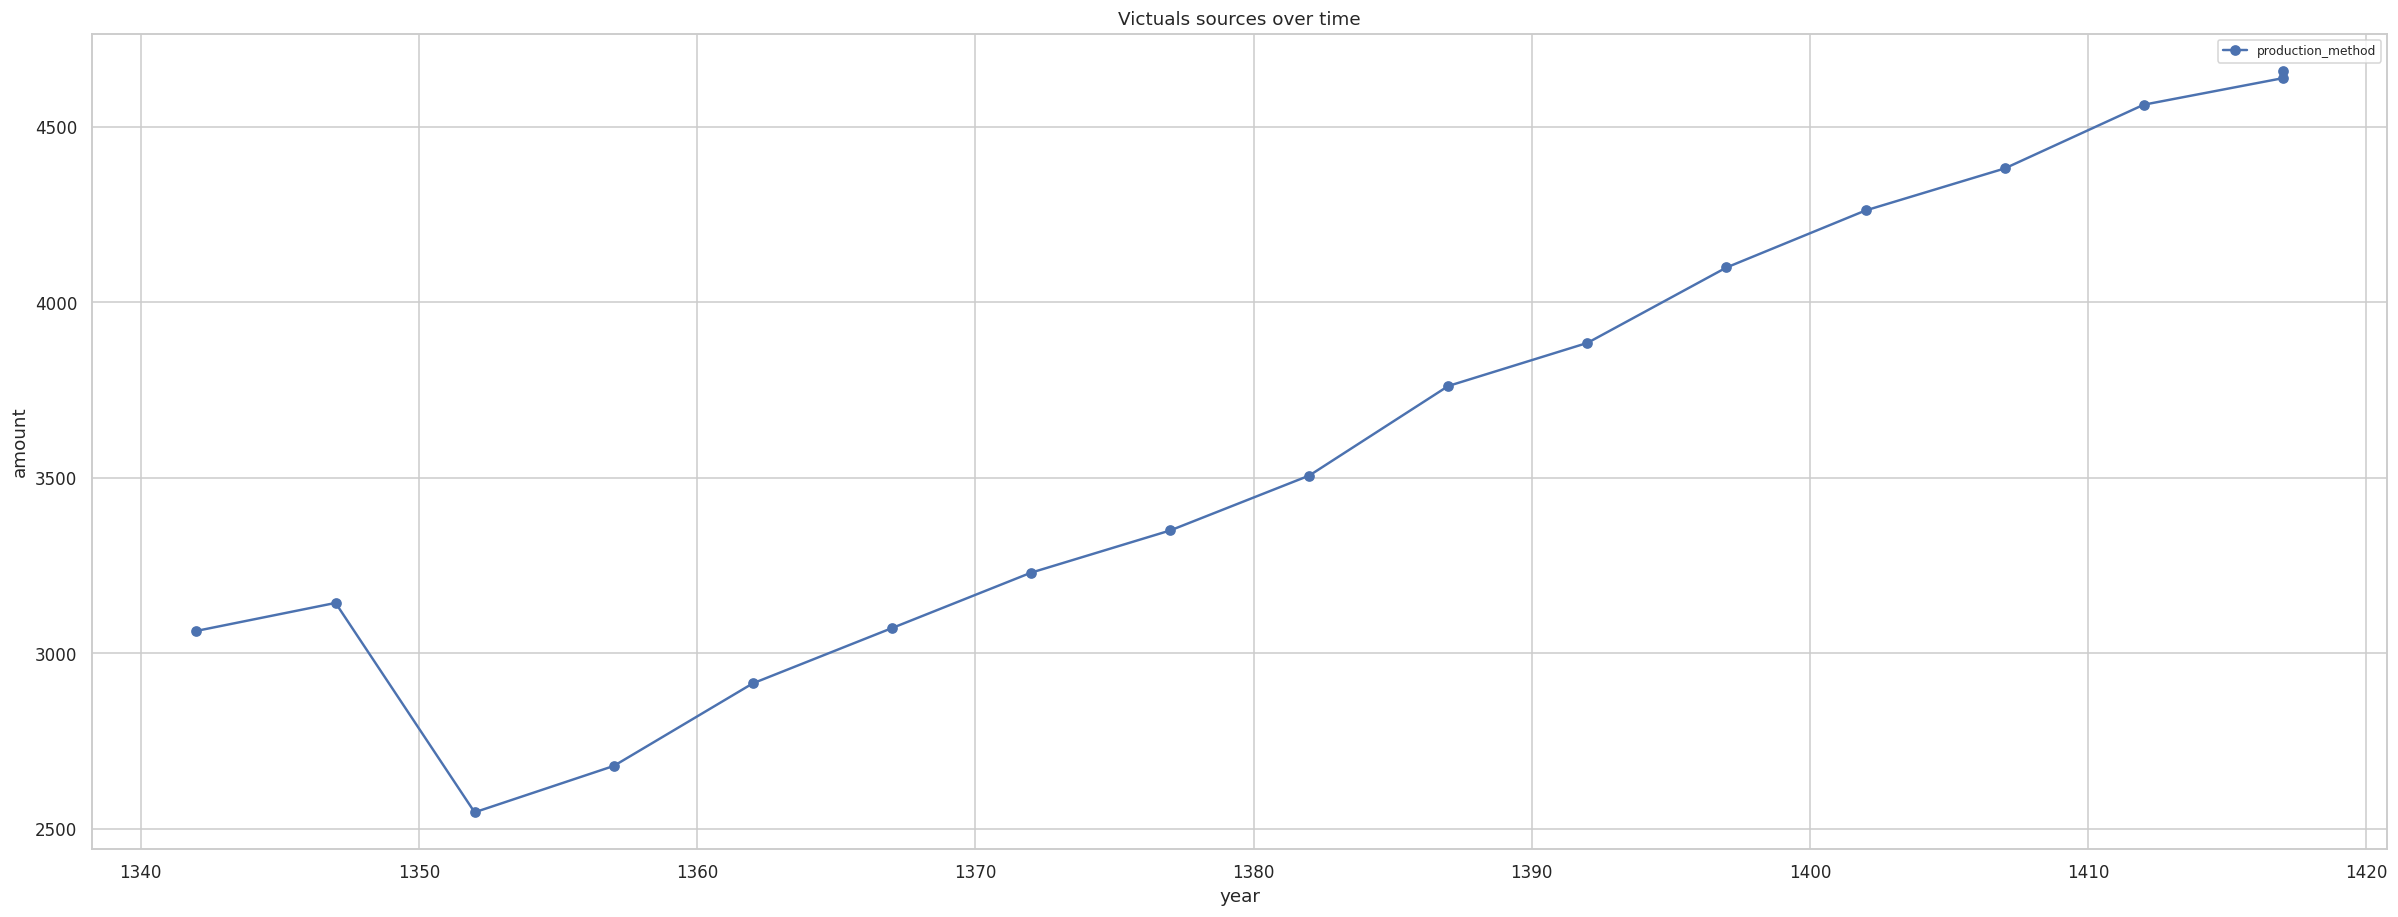

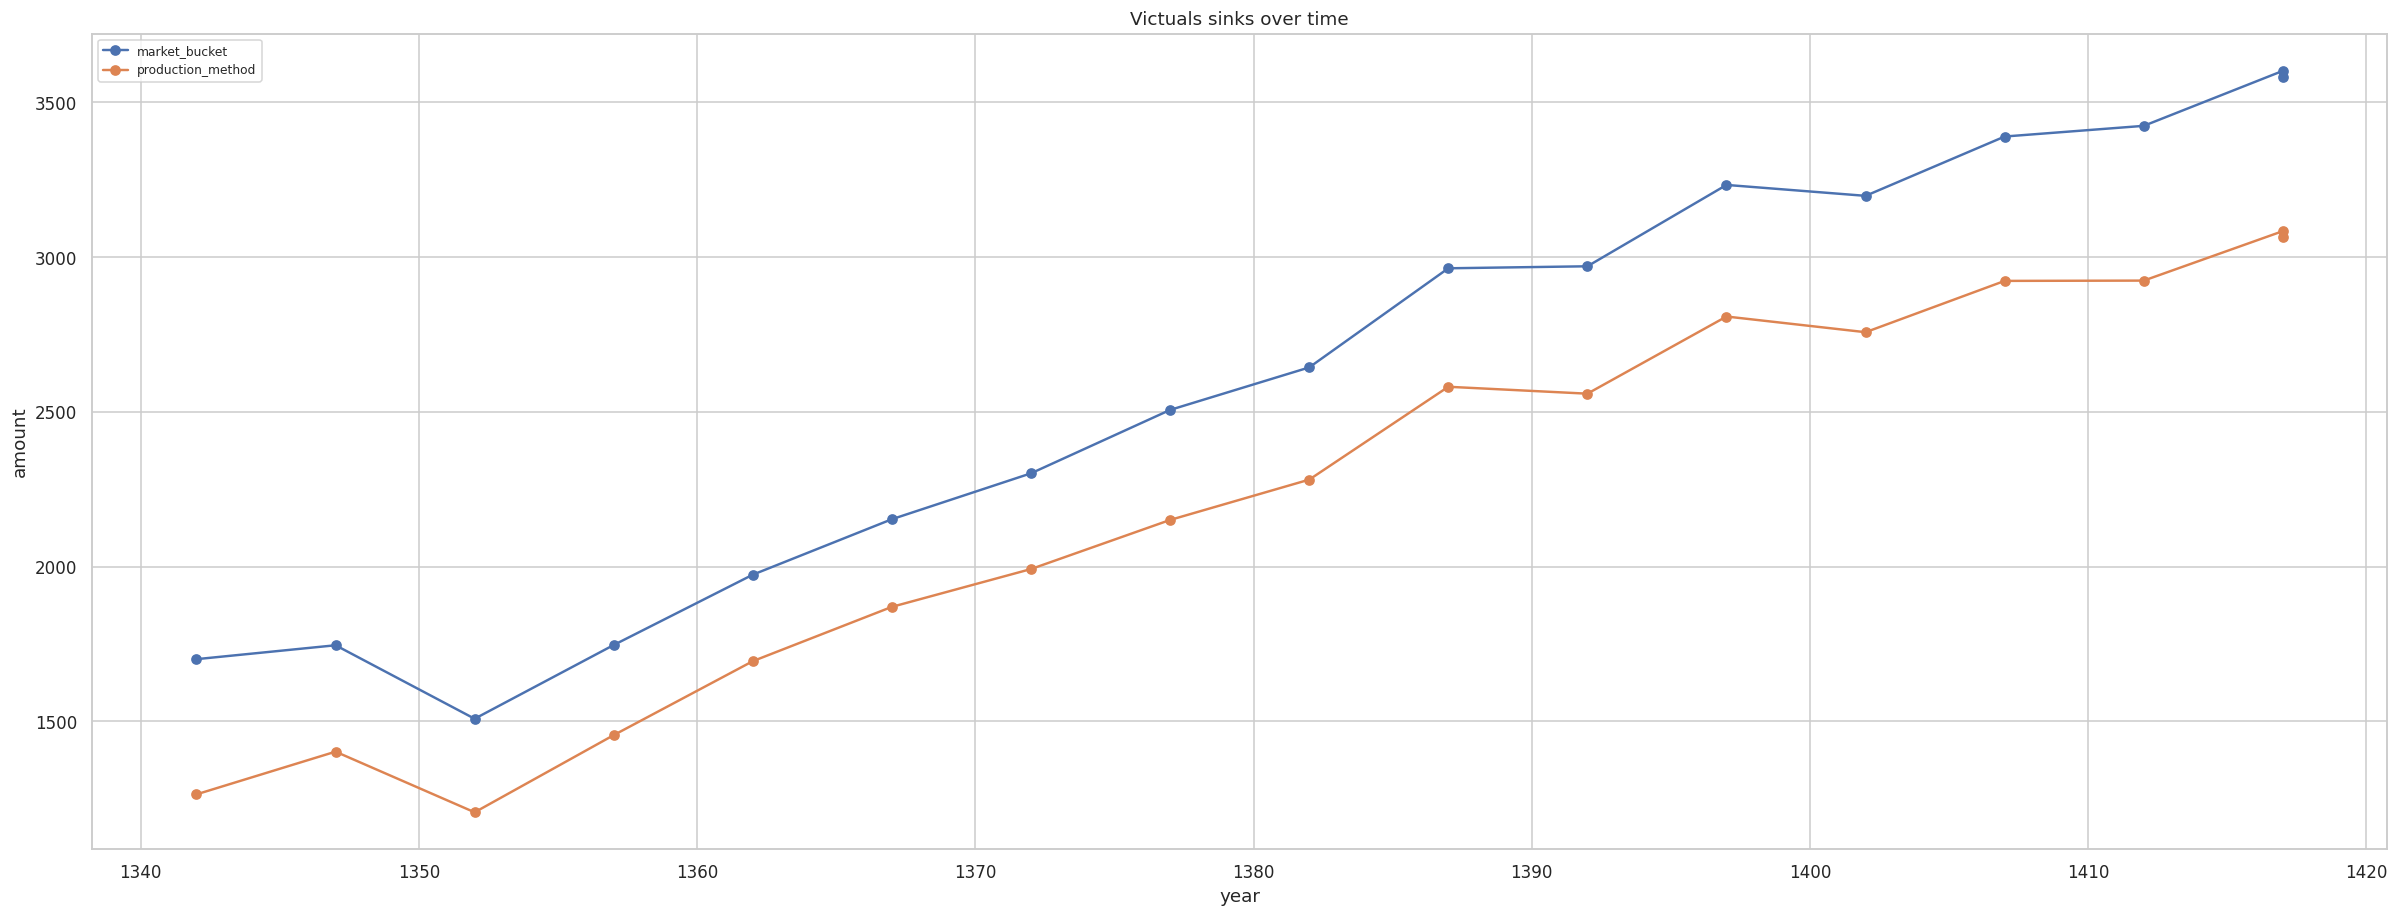

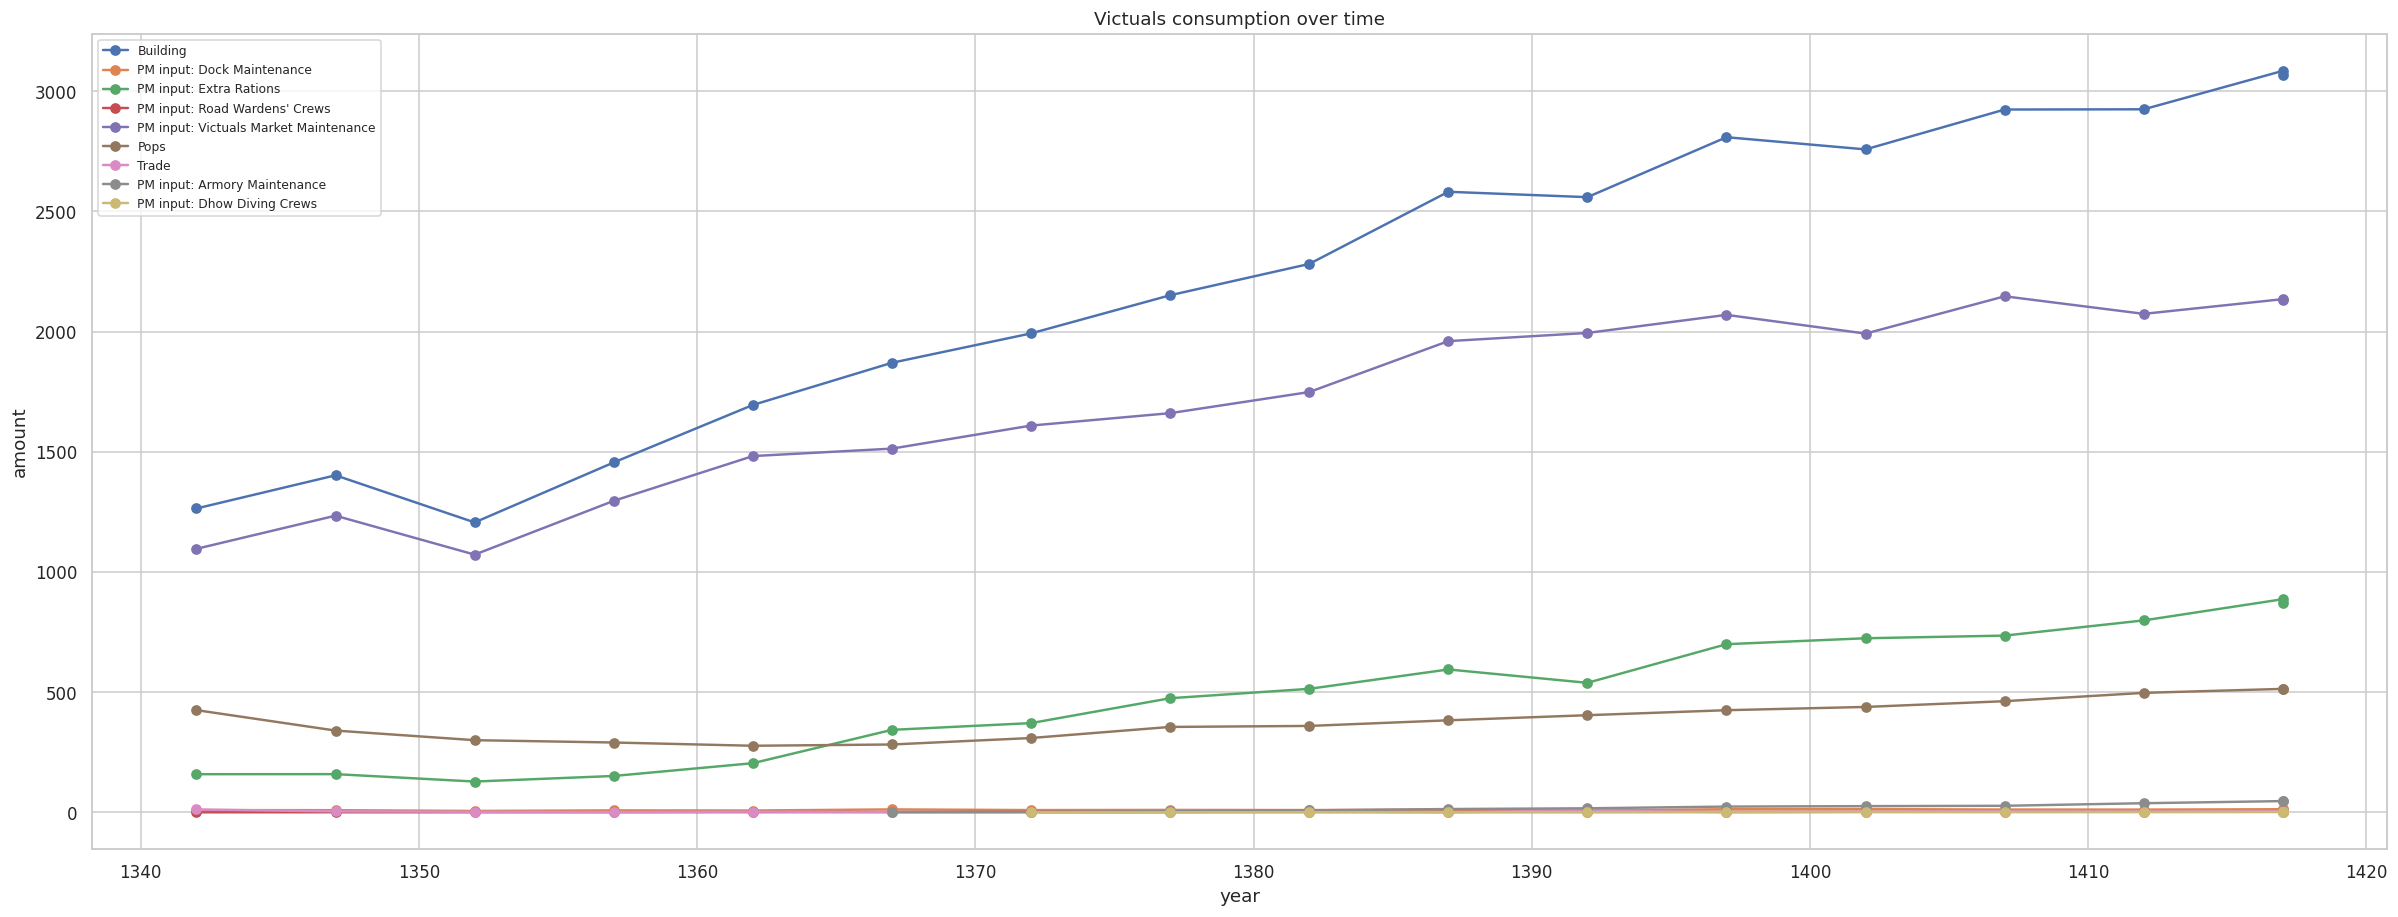

In [13]:
workbench.plot_flows(flows)


## Food Markets

In [14]:
food = workbench.food()
food_rank = food.rank
food_global = food.global_time_series
food_price_distribution = food.price_distribution
food_delta = food.delta


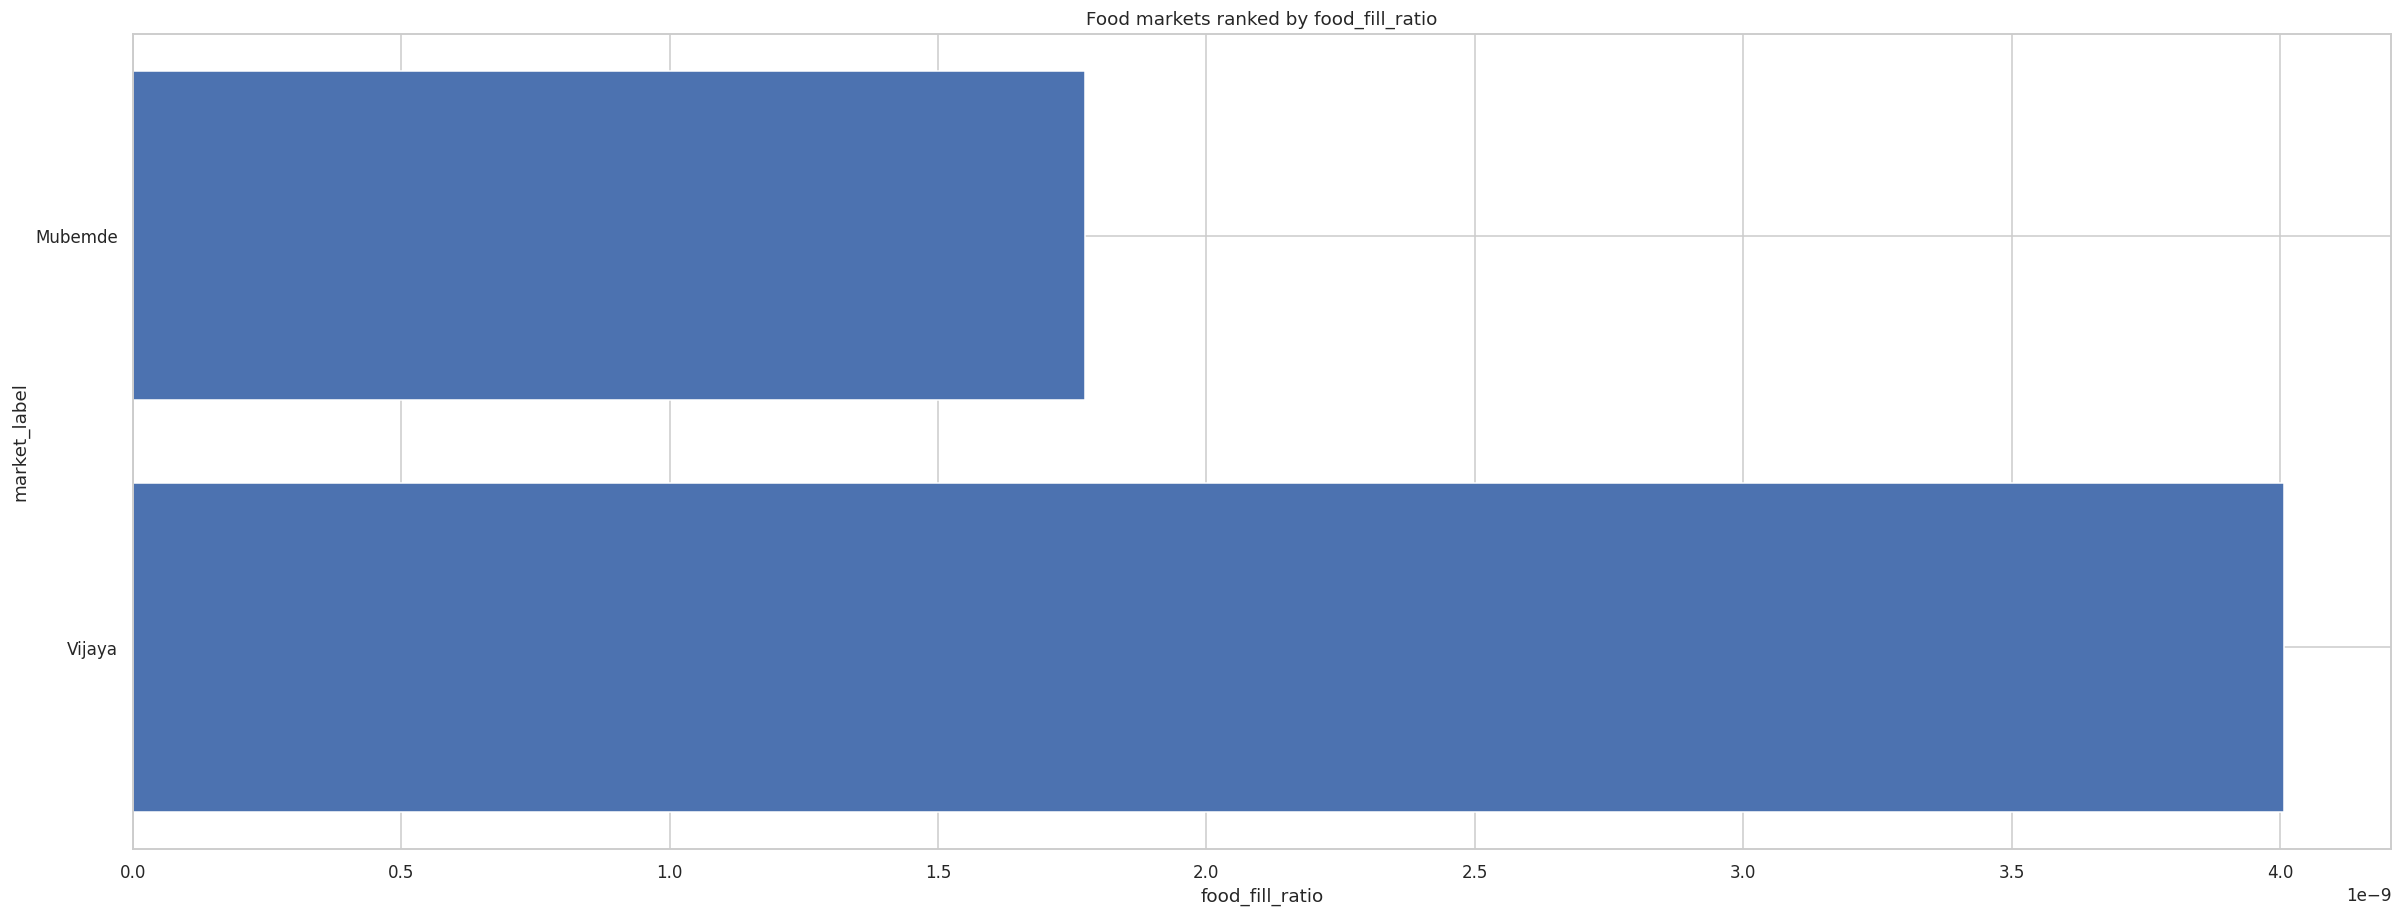

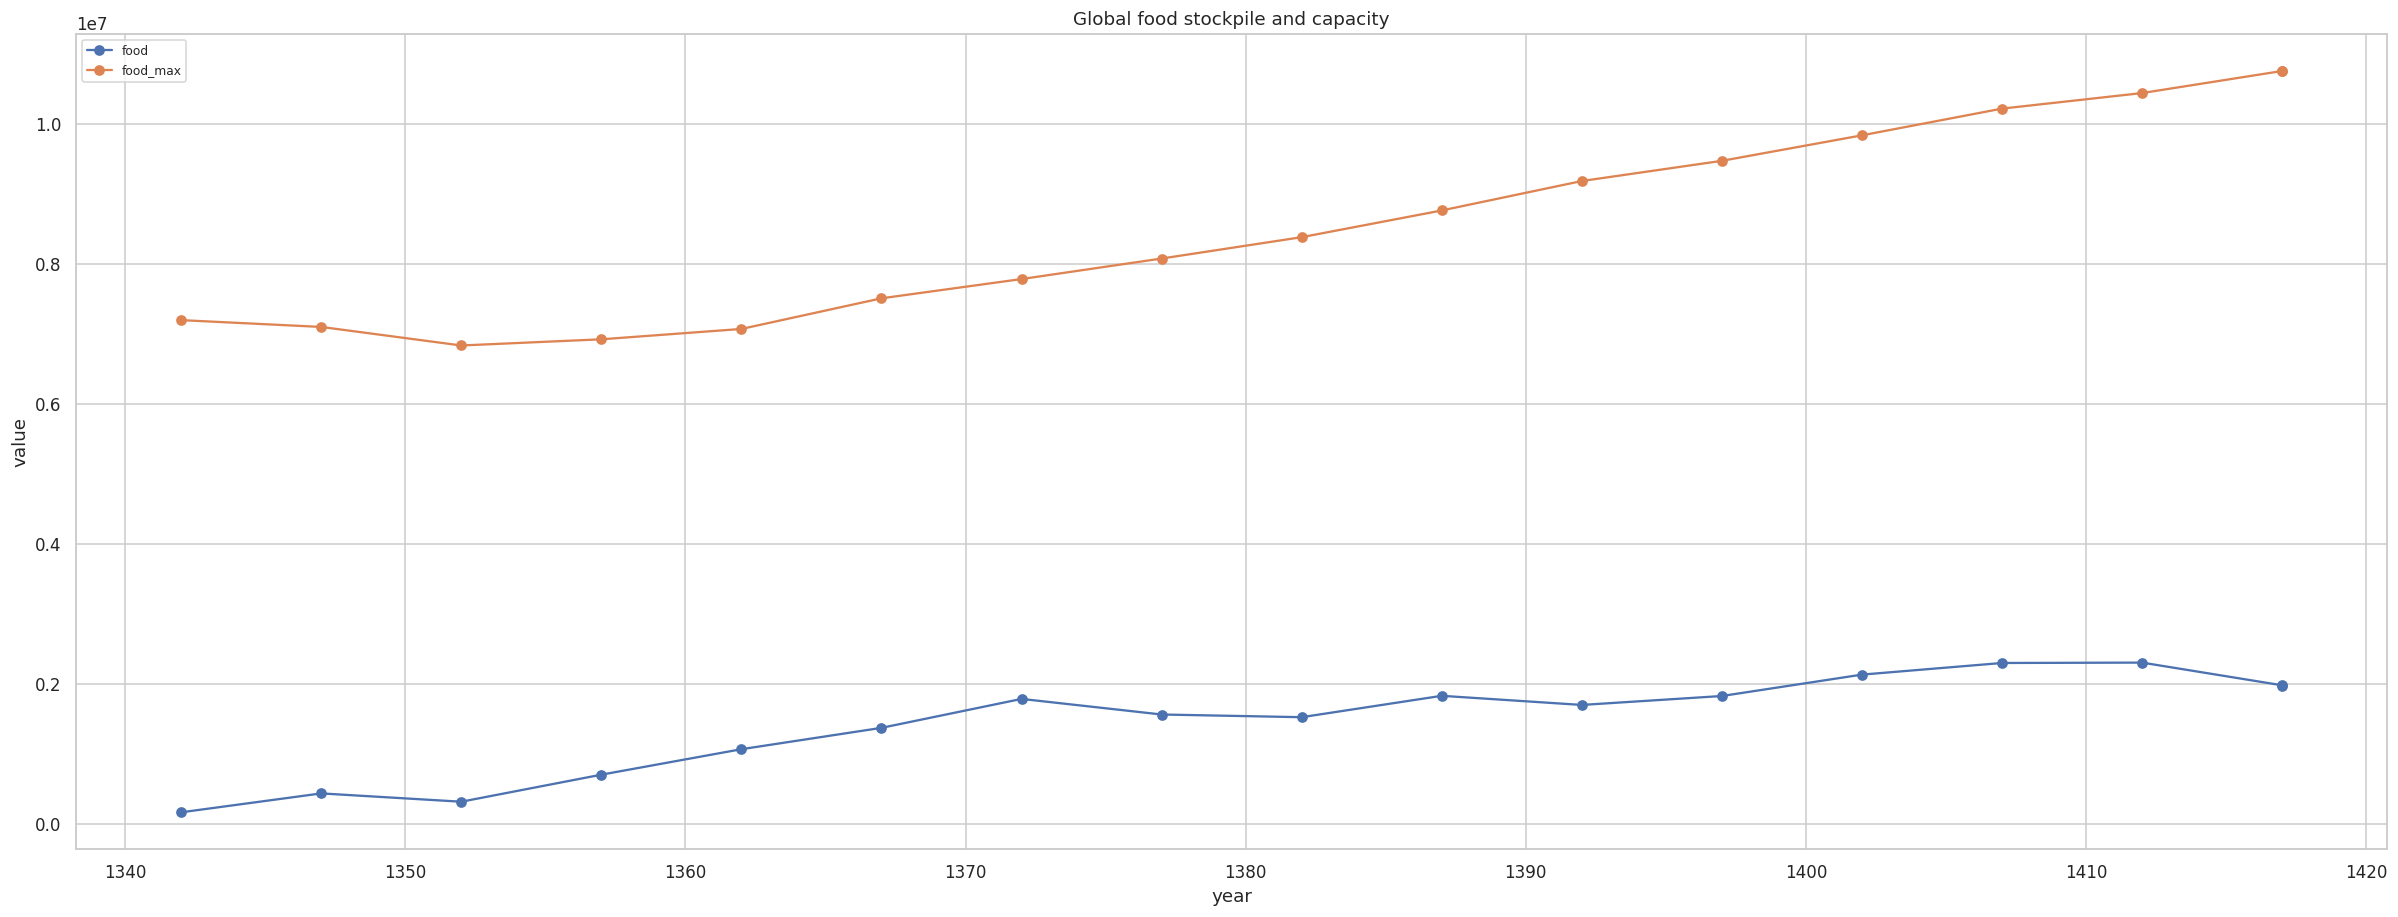

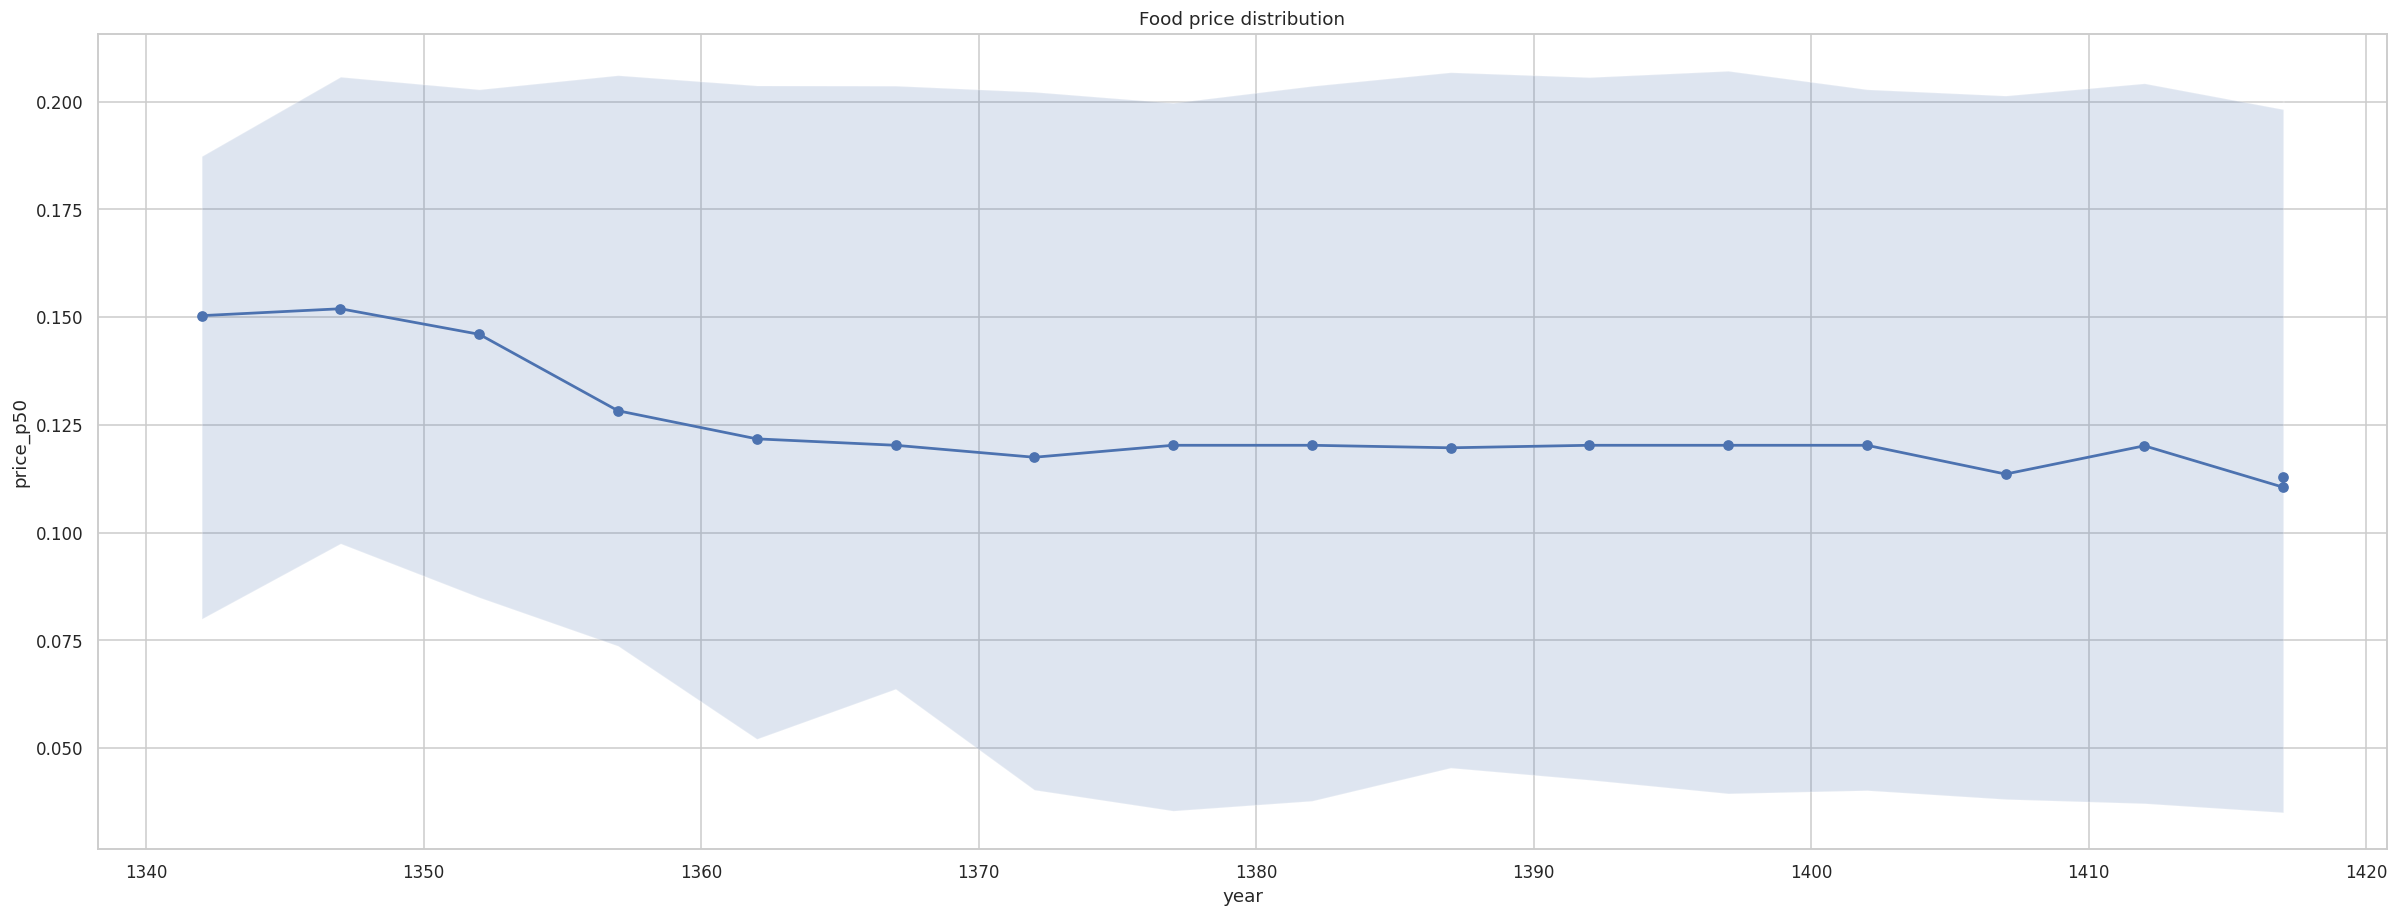

In [15]:
workbench.plot_food(food)


## Buildings And Production Methods

In [16]:
buildings = workbench.buildings()
building_latest = buildings.latest
building_ts = buildings.time_series
pm_adoption = buildings.pm_adoption
pm_preferences = buildings.pm_preferences
pm_regional_preferences_by_slot = buildings.pm_regional_preferences_by_slot
pm_slot_ts = buildings.pm_slot_time_series
pm_usage_by_slot_over_time = buildings.pm_usage_by_slot_over_time
pm_values = buildings.pm_values


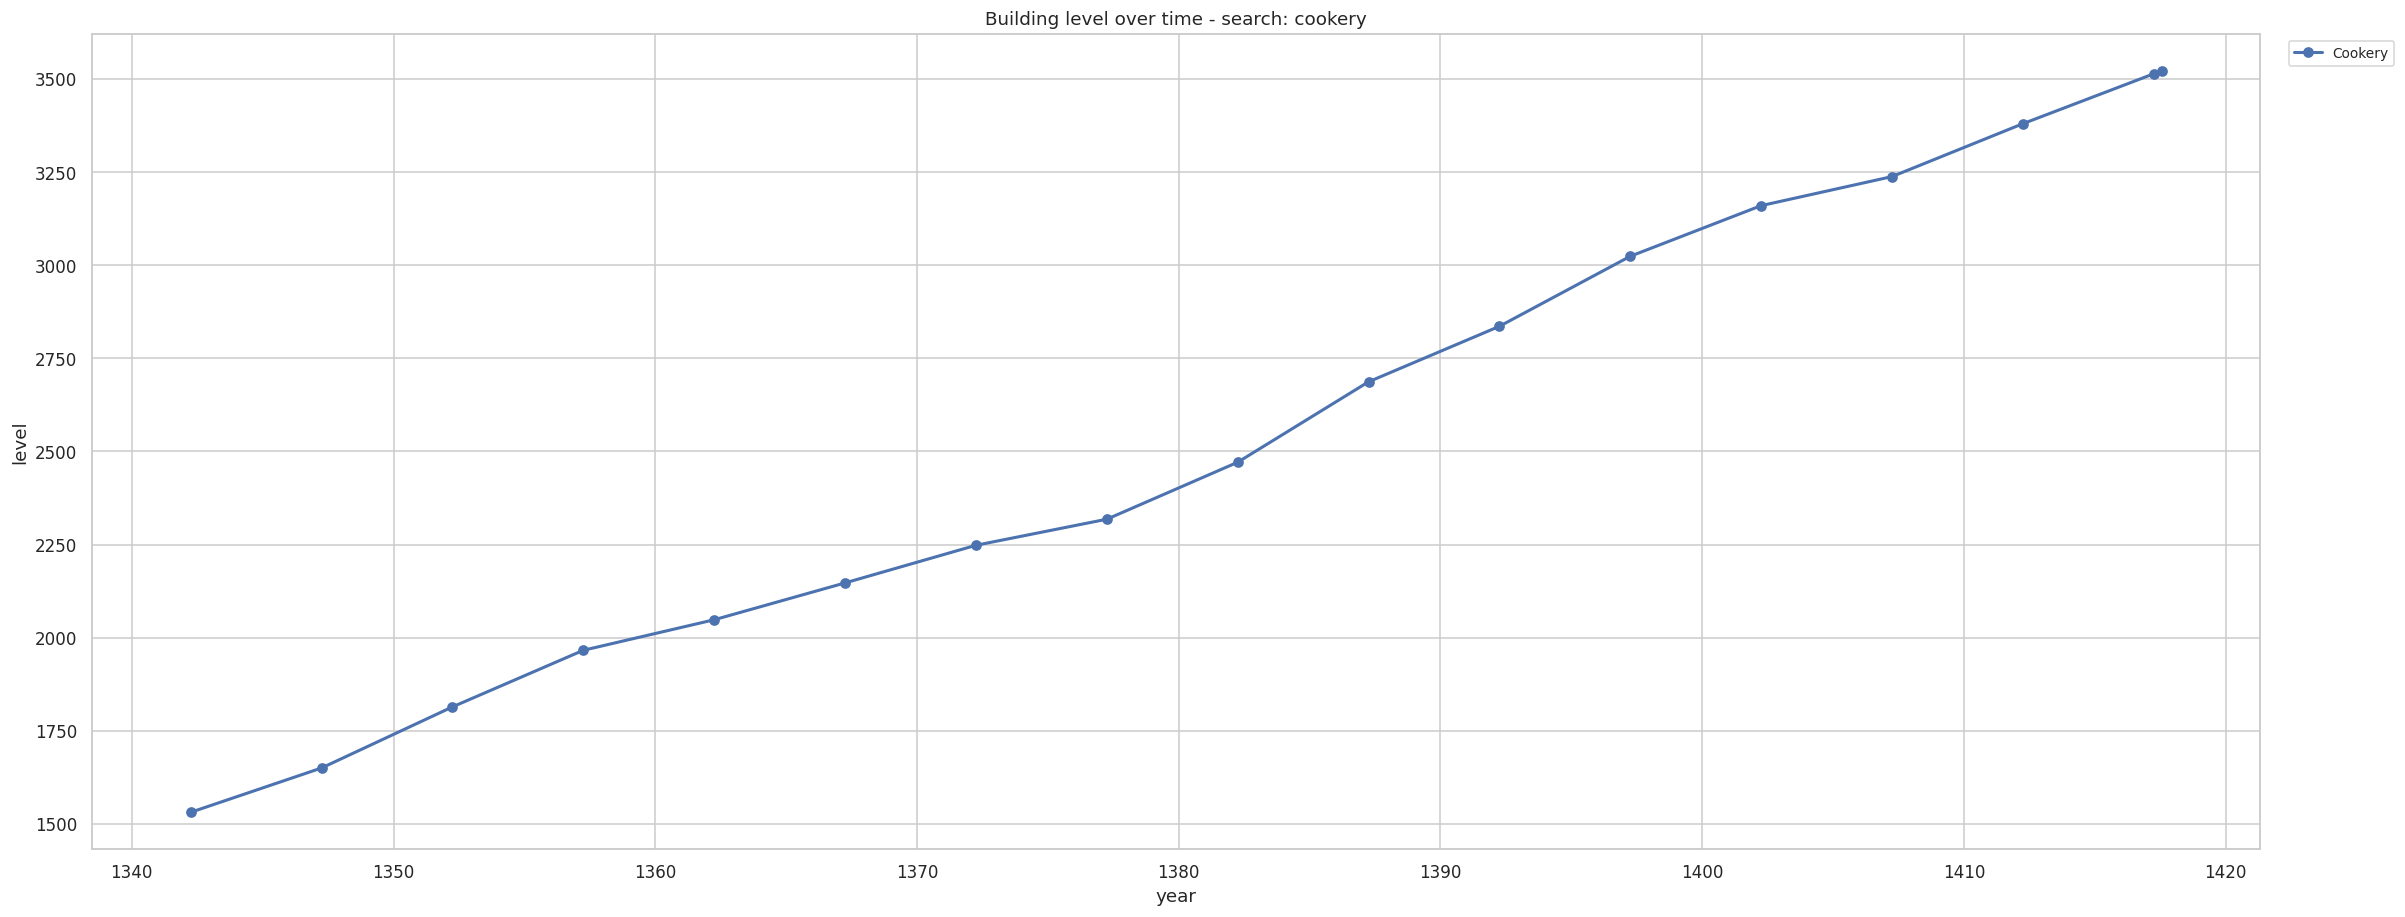

In [17]:
import matplotlib.pyplot as plt
import polars as pl
from IPython.display import display
from matplotlib.ticker import MaxNLocator

from eu5gameparser.clausewitz.syntax import CList
from eu5gameparser.load_order import load_merged_directory, load_profile

BUILDING_ABSOLUTE_FIGSIZE = (14, 6)


def _text_or_none(value: object | None) -> str | None:
    if value is None:
        return None
    text = str(value).strip()
    return text or None


def _clausewitz_string_list(value: object) -> list[str]:
    if isinstance(value, CList):
        return [str(item) for item in value.items]
    if value is None:
        return []
    return [str(value)]


def _building_custom_tags() -> pl.DataFrame:
    schema = {"building_type": pl.String, "custom_tags": pl.List(pl.String)}
    if ds.profile is None:
        return pl.DataFrame(schema=schema)
    try:
        profile = load_profile(ds.profile, ds.load_order_path)
        merged = load_merged_directory(profile, "building_types")
    except (FileNotFoundError, KeyError, OSError, pl.exceptions.PolarsError) as exc:
        print(f"Could not load building tags: {exc}")
        return pl.DataFrame(schema=schema)

    rows = []
    for entry in merged.entries:
        tags: list[str] = []
        if isinstance(entry.value, CList):
            for value in entry.value.values("custom_tags"):
                tags.extend(_clausewitz_string_list(value))
        rows.append({"building_type": entry.key, "custom_tags": sorted(set(tags))})
    return pl.DataFrame(rows, schema=schema)


def _selected_raw_buildings() -> pl.LazyFrame:
    files = ds.fact_files("buildings", playthrough_id=workbench.playthrough)
    if not files:
        return pl.DataFrame().lazy()
    frame = pl.scan_parquet(
        [str(path) for path in files],
        hive_partitioning=False,
        missing_columns="insert",
        extra_columns="ignore",
    )
    if START_DATE is not None:
        frame = frame.filter(pl.col("date_sort") >= int(START_DATE))
    if END_DATE is not None:
        frame = frame.filter(pl.col("date_sort") <= int(END_DATE))
    return frame.with_columns(
        (
            pl.col("year").cast(pl.Float64)
            + (pl.col("month").cast(pl.Float64) - 1.0) / 12.0
            + (pl.col("day").cast(pl.Float64) - 1.0) / 365.25
        ).alias("plot_year")
    )


def _selected_building_types() -> tuple[list[str] | None, pl.DataFrame, pl.DataFrame]:
    selected_sets: list[set[str]] = []
    if workbench.building_query is not None and "building_type" in workbench.building_matches.columns:
        selected_sets.append(set(workbench.building_matches.get_column("building_type").to_list()))

    tags = _building_custom_tags()
    tag_options = (
        tags.explode("custom_tags")
        .drop_nulls("custom_tags")
        .group_by("custom_tags")
        .agg(pl.len().alias("buildings"))
        .sort("custom_tags")
        if not tags.is_empty()
        else pl.DataFrame(schema={"custom_tags": pl.String, "buildings": pl.UInt32})
    )

    tag_filter = _text_or_none(globals().get("BUILDING_TAG_FILTER"))
    if tag_filter is None:
        tag_matches = tags.head(0)
    else:
        tag_matches = tags.filter(pl.col("custom_tags").list.contains(tag_filter))
        selected_sets.append(set(tag_matches.get_column("building_type").to_list()))

    if selected_sets:
        return sorted(set.intersection(*selected_sets)), tag_matches, tag_options
    return None, tag_matches, tag_options


def _building_absolute_time_series() -> tuple[pl.DataFrame, pl.DataFrame, pl.DataFrame, str]:
    selected_types, tag_matches, tag_options = _selected_building_types()
    buildings_raw = _selected_raw_buildings()
    building_columns = set(buildings_raw.collect_schema().names())
    metric = BUILDING_METRIC if BUILDING_METRIC in building_columns else "level"
    if selected_types is not None:
        buildings_raw = buildings_raw.filter(pl.col("building_type").is_in(selected_types))

    labels = ds.dim("building_types").select(["building_type", "building_label"]).lazy()
    frame = (
        buildings_raw.group_by(["snapshot_id", "date_sort", "year", "month", "day", "date", "plot_year", "building_type"])
        .agg(pl.sum(metric).alias(metric))
        .join(labels, on="building_type", how="left")
        .with_columns(pl.coalesce(pl.col("building_label"), pl.col("building_type")).alias("building_label"))
        .sort(["date_sort", "building_label"])
        .collect()
    )
    return frame, tag_matches, tag_options, metric


def _plot_building_absolute_time_series(frame: pl.DataFrame, metric: str) -> pl.DataFrame:
    if frame.is_empty() or not {"plot_year", "date_sort", "building_label", metric}.issubset(frame.columns):
        print("No rows")
        return frame

    latest_date = frame.get_column("date_sort").max()
    top_labels = (
        frame.filter(pl.col("date_sort") == latest_date)
        .sort(metric, descending=True)
        .get_column("building_label")
        .head(TOP_N)
        .to_list()
    )
    plot_frame = frame.filter(pl.col("building_label").is_in(top_labels)).sort(["building_label", "date_sort"])
    if plot_frame.is_empty():
        print("No rows")
        return plot_frame

    title_parts = [f"Building {metric} over time"]
    tag_filter = _text_or_none(globals().get("BUILDING_TAG_FILTER"))
    if tag_filter is not None:
        title_parts.append(f"tag: {tag_filter}")
    if workbench.building_query is not None:
        title_parts.append(f"search: {workbench.building_query}")

    fig, ax = plt.subplots(figsize=BUILDING_ABSOLUTE_FIGSIZE)
    for label in top_labels:
        series = plot_frame.filter(pl.col("building_label") == label).sort("date_sort")
        ax.plot(
            series["plot_year"].to_list(),
            series[metric].to_list(),
            marker="o",
            linewidth=2.0,
            label=label,
        )
    ax.set_title(" - ".join(title_parts))
    ax.set_xlabel("year")
    ax.set_ylabel(metric)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
    fig.tight_layout()
    display(fig, include=["image/png"])
    plt.close(fig)
    return plot_frame


building_absolute_ts, building_tag_matches, building_tag_options, building_absolute_metric = _building_absolute_time_series()
building_absolute_ts_top = _plot_building_absolute_time_series(building_absolute_ts, building_absolute_metric)


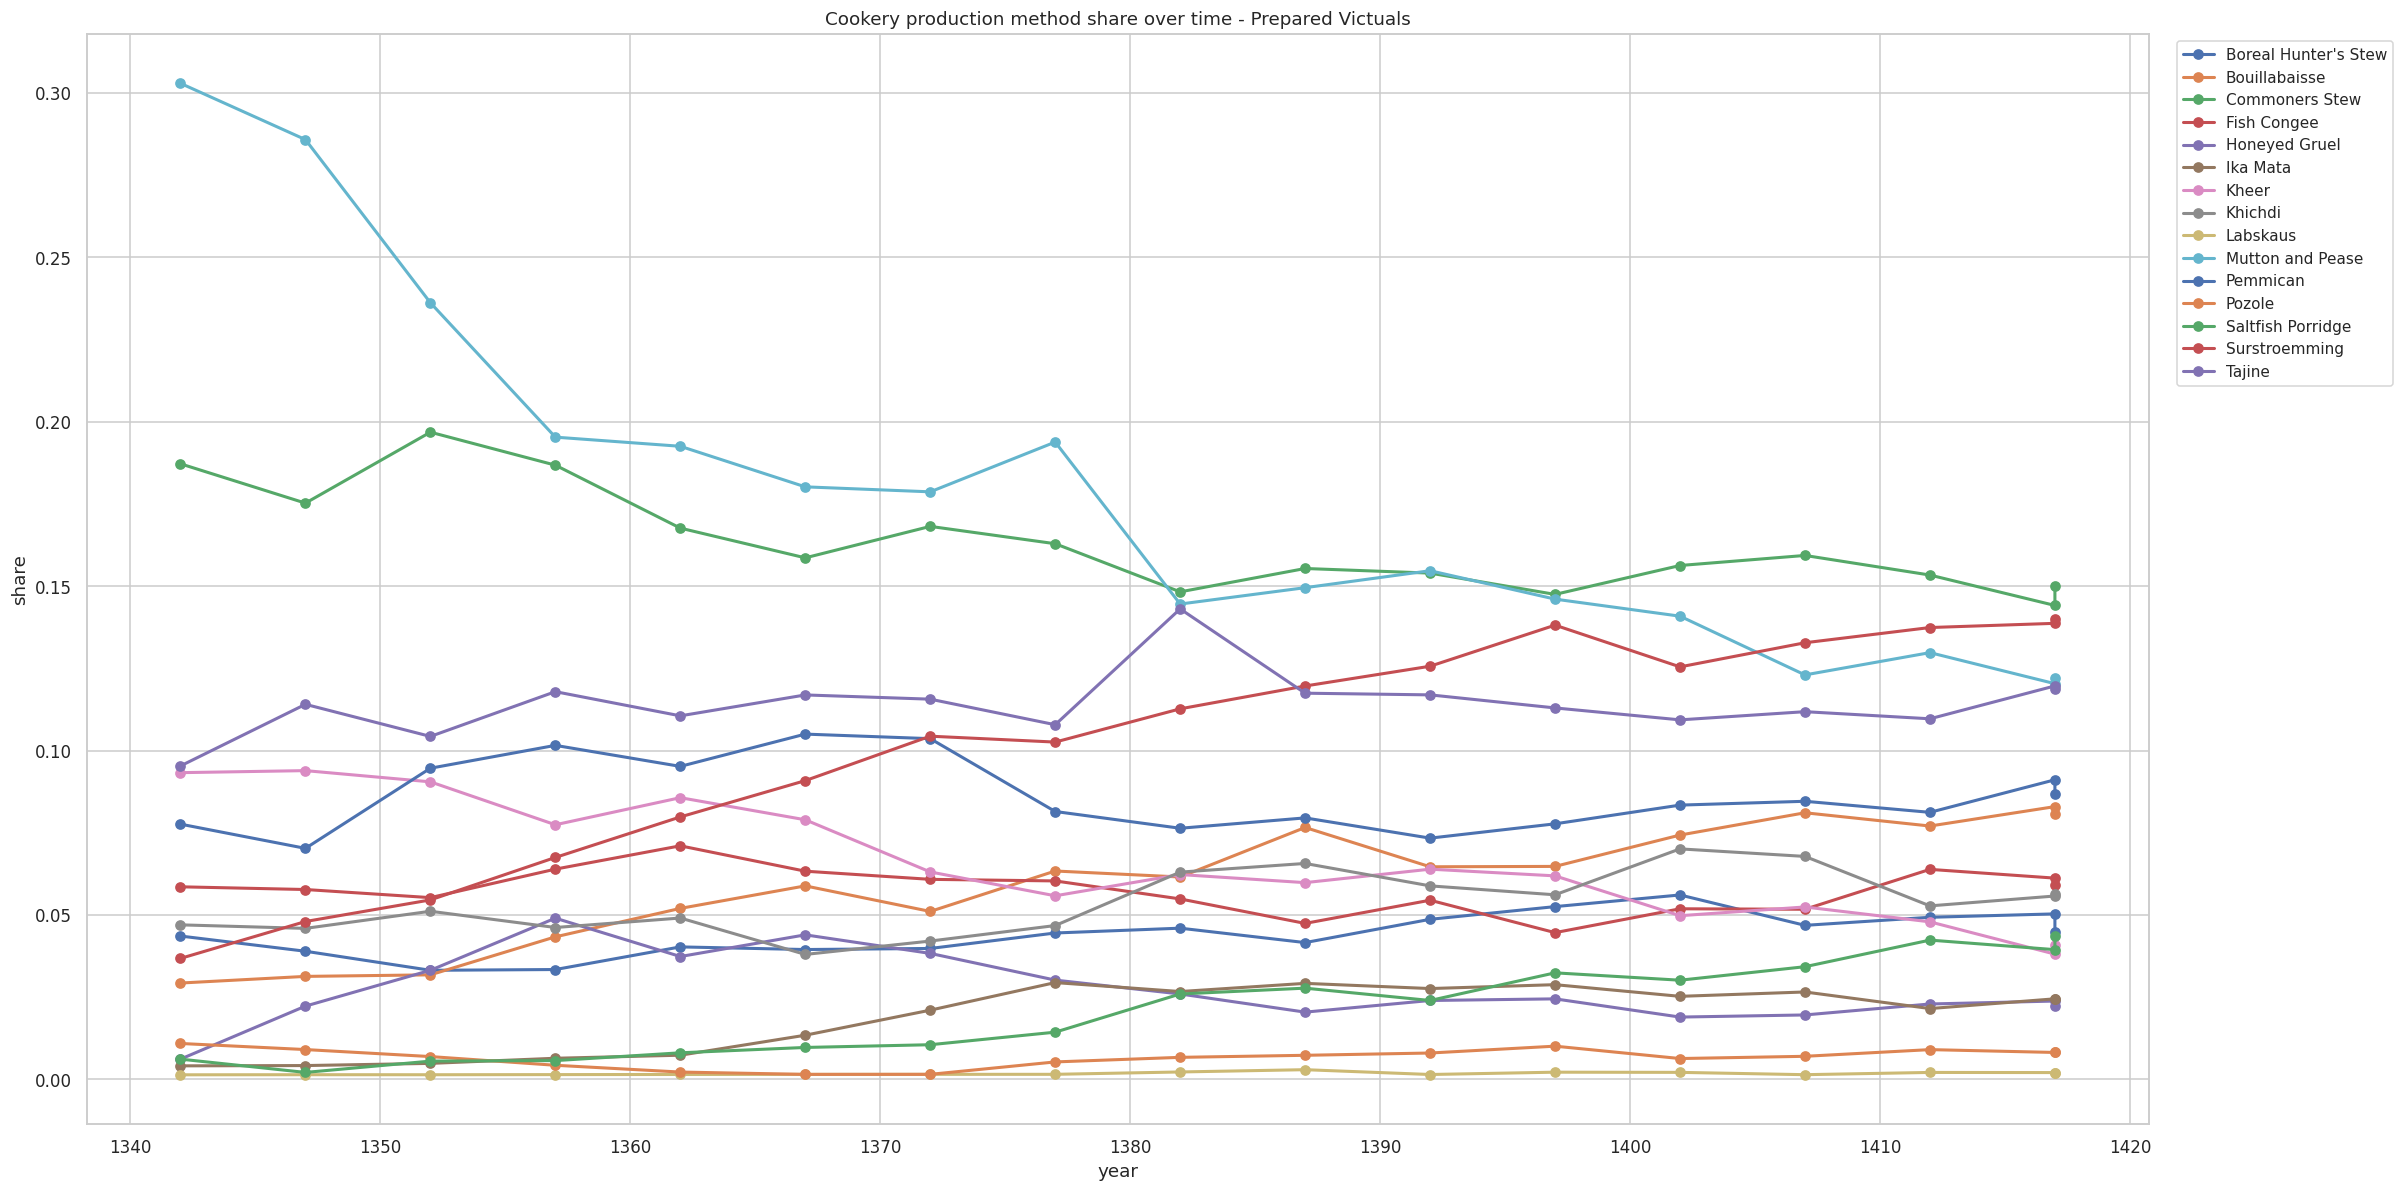

In [18]:
import matplotlib.pyplot as plt
import polars as pl
from IPython.display import display

PRODUCTION_METHOD_FIGSIZE = (22, 11)

SLOT_INDEX = 0
null_slot_rows = pm_slot_ts.filter(pl.col("production_method_group_index").is_null())
if null_slot_rows.height == pm_slot_ts.height:
    if SLOT_INDEX == 0:
        pm_slot_plot_ts = pm_slot_ts.with_columns(pl.col("slot_label").alias("_plot_slot_key"))
        slot_key = pm_slot_plot_ts.get_column("_plot_slot_key").drop_nulls().unique().sort().to_list()[0]
    else:
        pm_slot_plot_ts = pm_slot_ts.head(0).with_columns(pl.lit(None, dtype=pl.String).alias("_plot_slot_key"))
        slot_key = None
elif not null_slot_rows.is_empty():
    raise ValueError(
        "pm_slot_ts contains rows without production_method_group_index. "
        "Rerun the buildings cell or rebuild the notebook dataset; slot plots require resolved slot metadata."
    )
else:
    pm_slot_plot_ts = pm_slot_ts.with_columns(
        pl.col("production_method_group_index").cast(pl.String).alias("_plot_slot_key")
    )
    slot_key = str(SLOT_INDEX)

if slot_key is not None:
    slot_frame = pm_slot_plot_ts.filter(pl.col("_plot_slot_key") == slot_key).sort("year")

    if slot_frame.is_empty():
        raise ValueError(f"slot {slot_key}: no data")

    slot_name = (
        slot_frame.get_column("slot_label").drop_nulls().to_list() or [f"slot {slot_key}"]
    )[0]
    methods = slot_frame.get_column("production_method_label").unique().sort().to_list()

    fig, ax = plt.subplots(figsize=PRODUCTION_METHOD_FIGSIZE)
    for method in methods:
        series = slot_frame.filter(pl.col("production_method_label") == method).sort("year")
        ax.plot(
            series["year"].to_list(),
            series["share"].to_list(),
            marker="o",
            linewidth=2.0,
            label=method,
        )
    ax.set_title(
        f"{workbench.building_label} production method share over time - {slot_name}"
    )
    ax.set_xlabel("year")
    ax.set_ylabel("share")
    ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=10)
    fig.tight_layout()
    display(fig, include=["image/png"])
    plt.close(fig)


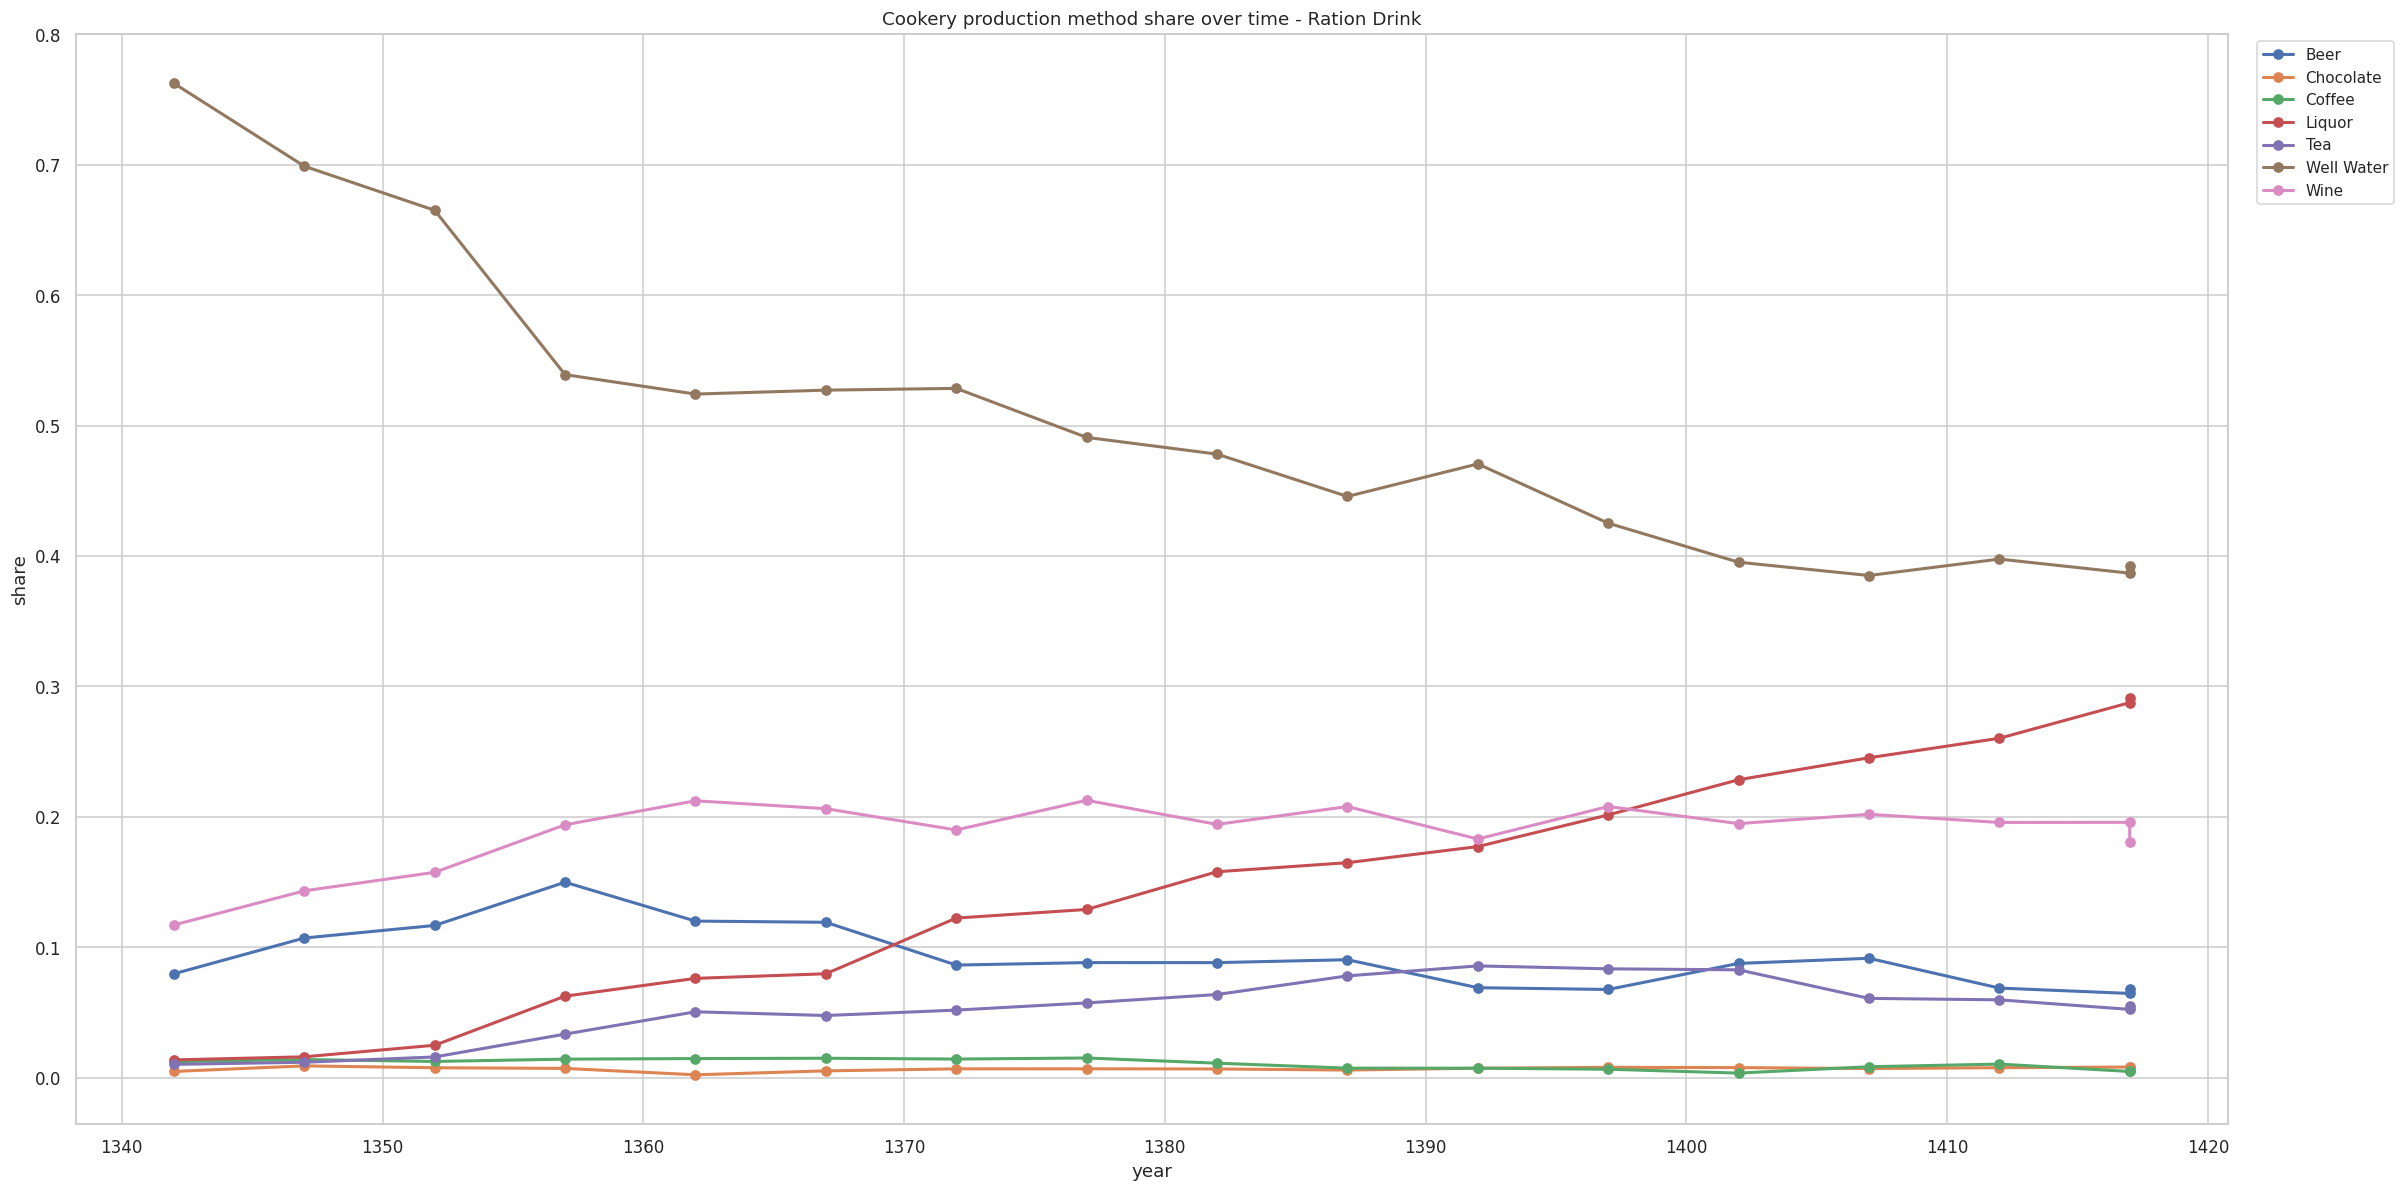

In [19]:
import matplotlib.pyplot as plt
import polars as pl
from IPython.display import display

PRODUCTION_METHOD_FIGSIZE = (22, 11)

SLOT_INDEX = 1
null_slot_rows = pm_slot_ts.filter(pl.col("production_method_group_index").is_null())
if null_slot_rows.height == pm_slot_ts.height:
    if SLOT_INDEX == 0:
        pm_slot_plot_ts = pm_slot_ts.with_columns(pl.col("slot_label").alias("_plot_slot_key"))
        slot_key = pm_slot_plot_ts.get_column("_plot_slot_key").drop_nulls().unique().sort().to_list()[0]
    else:
        pm_slot_plot_ts = pm_slot_ts.head(0).with_columns(pl.lit(None, dtype=pl.String).alias("_plot_slot_key"))
        slot_key = None
elif not null_slot_rows.is_empty():
    raise ValueError(
        "pm_slot_ts contains rows without production_method_group_index. "
        "Rerun the buildings cell or rebuild the notebook dataset; slot plots require resolved slot metadata."
    )
else:
    pm_slot_plot_ts = pm_slot_ts.with_columns(
        pl.col("production_method_group_index").cast(pl.String).alias("_plot_slot_key")
    )
    slot_key = str(SLOT_INDEX)

if slot_key is not None:
    slot_frame = pm_slot_plot_ts.filter(pl.col("_plot_slot_key") == slot_key).sort("year")

    if slot_frame.is_empty():
        raise ValueError(f"slot {slot_key}: no data")

    slot_name = (
        slot_frame.get_column("slot_label").drop_nulls().to_list() or [f"slot {slot_key}"]
    )[0]
    methods = slot_frame.get_column("production_method_label").unique().sort().to_list()

    fig, ax = plt.subplots(figsize=PRODUCTION_METHOD_FIGSIZE)
    for method in methods:
        series = slot_frame.filter(pl.col("production_method_label") == method).sort("year")
        ax.plot(
            series["year"].to_list(),
            series["share"].to_list(),
            marker="o",
            linewidth=2.0,
            label=method,
        )
    ax.set_title(
        f"{workbench.building_label} production method share over time - {slot_name}"
    )
    ax.set_xlabel("year")
    ax.set_ylabel("share")
    ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=10)
    fig.tight_layout()
    display(fig, include=["image/png"])
    plt.close(fig)


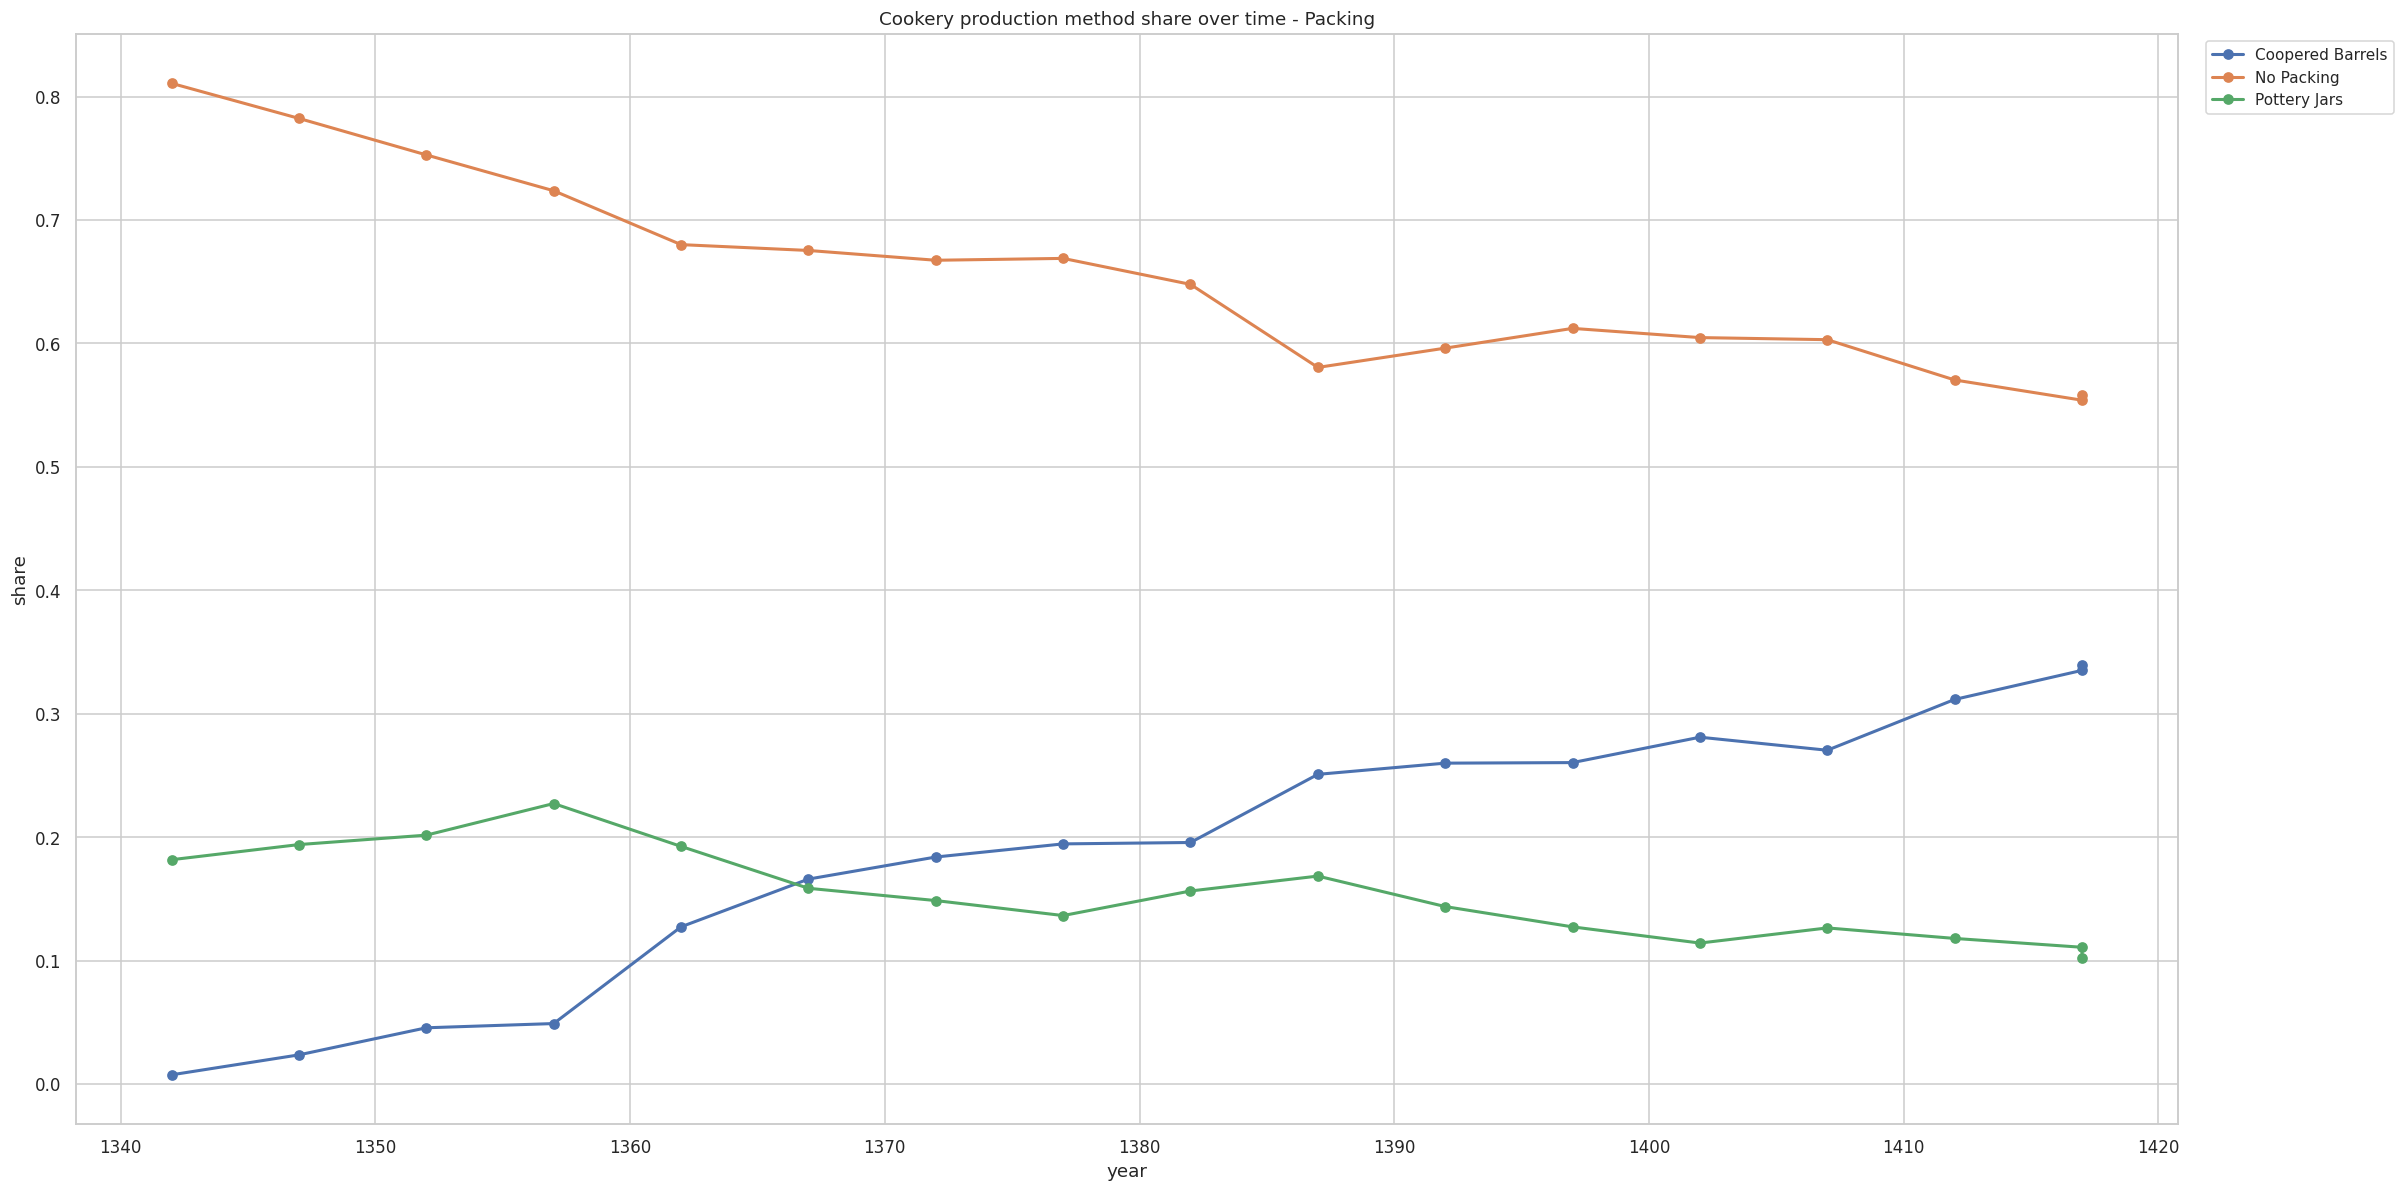

In [20]:
import matplotlib.pyplot as plt
import polars as pl
from IPython.display import display

PRODUCTION_METHOD_FIGSIZE = (22, 11)

SLOT_INDEX = 2
null_slot_rows = pm_slot_ts.filter(pl.col("production_method_group_index").is_null())
if null_slot_rows.height == pm_slot_ts.height:
    if SLOT_INDEX == 0:
        pm_slot_plot_ts = pm_slot_ts.with_columns(pl.col("slot_label").alias("_plot_slot_key"))
        slot_key = pm_slot_plot_ts.get_column("_plot_slot_key").drop_nulls().unique().sort().to_list()[0]
    else:
        pm_slot_plot_ts = pm_slot_ts.head(0).with_columns(pl.lit(None, dtype=pl.String).alias("_plot_slot_key"))
        slot_key = None
elif not null_slot_rows.is_empty():
    raise ValueError(
        "pm_slot_ts contains rows without production_method_group_index. "
        "Rerun the buildings cell or rebuild the notebook dataset; slot plots require resolved slot metadata."
    )
else:
    pm_slot_plot_ts = pm_slot_ts.with_columns(
        pl.col("production_method_group_index").cast(pl.String).alias("_plot_slot_key")
    )
    slot_key = str(SLOT_INDEX)

if slot_key is not None:
    slot_frame = pm_slot_plot_ts.filter(pl.col("_plot_slot_key") == slot_key).sort("year")

    if slot_frame.is_empty():
        raise ValueError(f"slot {slot_key}: no data")

    slot_name = (
        slot_frame.get_column("slot_label").drop_nulls().to_list() or [f"slot {slot_key}"]
    )[0]
    methods = slot_frame.get_column("production_method_label").unique().sort().to_list()

    fig, ax = plt.subplots(figsize=PRODUCTION_METHOD_FIGSIZE)
    for method in methods:
        series = slot_frame.filter(pl.col("production_method_label") == method).sort("year")
        ax.plot(
            series["year"].to_list(),
            series["share"].to_list(),
            marker="o",
            linewidth=2.0,
            label=method,
        )
    ax.set_title(
        f"{workbench.building_label} production method share over time - {slot_name}"
    )
    ax.set_xlabel("year")
    ax.set_ylabel("share")
    ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=10)
    fig.tight_layout()
    display(fig, include=["image/png"])
    plt.close(fig)
